# Tennis Dataset — Full Analysis Notebook

## Imports
All libraries are imported here once and apply to the entire notebook.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Data Loading
All CSV files are loaded here once.

In [47]:
home_team = pd.read_csv("../home_team.csv")
away_team = pd.read_csv("../away_team.csv")
home_score = pd.read_csv("../home_team_score.csv")
away_score = pd.read_csv("../away_team_score.csv")
stats_df = pd.read_csv("../statistics.csv")
round_df = pd.read_csv("../round.csv")
event_df = pd.read_csv("../event.csv")
match_time_df = pd.read_csv("../time.csv")
tournament_df = pd.read_csv("../tournament.csv")
venue_df = pd.read_csv("../venue.csv")
votes_df = pd.read_csv("../votes.csv")
pbp_df = pd.read_csv("../pbp.csv")


## Exploratory Data Analysis
A quick look at each dataframe before cleaning.

In [48]:
print("shape:", home_team.shape)
print("\n--- Data Types ---\n")
print(home_team.dtypes)


shape: (25610, 18)

--- Data Types ---

match_id           int64
name                 str
slug                 str
gender               str
user_count         int64
residence            str
birthplace           str
height           float64
weight           float64
plays                str
turned_pro       float64
current_prize    float64
total_prize      float64
player_id          int64
current_rank     float64
name_code            str
country              str
full_name            str
dtype: object


In [49]:
print("\n--- Null Counts ---\n")
print(home_team.isnull().sum())
print("\n--- Duplicate Rows ---")
print(home_team.duplicated().sum())


--- Null Counts ---

match_id             0
name                 0
slug                 0
gender              35
user_count           0
residence        18423
birthplace       10836
height           11287
weight           18578
plays            13126
turned_pro       20806
current_prize      130
total_prize         69
player_id            0
current_rank       273
name_code            0
country              9
full_name            0
dtype: int64

--- Duplicate Rows ---
7710


In [50]:
home_team.head()

,match_id,name,slug,gender,user_count,residence,birthplace,height,weight,plays,turned_pro,current_prize,total_prize,player_id,current_rank,name_code,country,full_name
0,11998445,Cazaux A.,cazaux-arthur,M,4481,NaN,"Montpellier, France",1.83,NaN,right-handed,NaN,233290.0,643582.0,287803,86.0,CAZ,France,"Cazaux, Arthur"
1,11998446,Lestienne C.,lestienne-constant,M,2032,"Paris, France","Amiens, France",1.80,72.0,right-handed,2012.0,105335.0,1404567.0,62790,99.0,LES,France,"Lestienne, Constant"
2,11998447,Ćorić B.,coric-borna,M,12414,"Dubai, UAE","Zagreb, Croatia",1.88,85.0,right-handed,2013.0,208593.0,9947986.0,64580,31.0,COR,Croatia,"Ćorić, Borna"
3,11998448,Mmoh M.,mmoh-michael,M,2206,"Bradenton, FL, USA","Riyadh, Saudi Arabia",1.88,90.0,right-handed,2016.0,47928.0,1775118.0,131442,122.0,MMO,USA,"Mmoh, Michael"
4,11998449,Paire B.,paire-benoit,M,6089,"Geneva, Switzerland","Avignon, France",1.96,80.0,right-handed,2007.0,33248.0,8622687.0,22218,110.0,PAI,France,"Paire, Benoit"


In [51]:
print("shape:", away_team.shape)
print("\n--- Data Types ---\n")
print(away_team.dtypes)


shape: (24203, 18)

--- Data Types ---

match_id           int64
name                 str
slug                 str
gender               str
user_count         int64
residence            str
birthplace           str
height           float64
weight           float64
plays                str
turned_pro       float64
current_prize    float64
total_prize      float64
player_id          int64
current_rank     float64
name_code            str
country              str
full_name            str
dtype: object


In [52]:
print("\n--- Null Counts ---\n")
print(away_team.isnull().sum())
print("\n--- Duplicate Rows ---")
print(away_team.duplicated().sum())


--- Null Counts ---

match_id             0
name                 0
slug                 0
gender              33
user_count           0
residence        17185
birthplace       10308
height           10665
weight           17293
plays            12244
turned_pro       19476
current_prize      226
total_prize        133
player_id            0
current_rank       325
name_code            0
country              5
full_name            0
dtype: int64

--- Duplicate Rows ---
7322


In [53]:
away_team.head()

,match_id,name,slug,gender,user_count,residence,birthplace,height,weight,plays,turned_pro,current_prize,total_prize,player_id,current_rank,name_code,country,full_name
0,11998445,Auger-Aliassime F.,auger-aliassime-felix,M,23318,"Monte Carlo, Monaco","Montreal, Canada",1.93,87.0,right-handed,2017.0,218538.0,10166964.0,192013,30.0,AUG,Canada,"Auger-Aliassime, Felix"
1,11998446,Cobolli F.,flavio-cobolli,M,5995,Rome,"Florence, Italy",1.83,71.0,right-handed,NaN,178358.0,808536.0,273680,69.0,COB,Italy,Flavio Cobolli
2,11998447,Martínez P.,martinez-pedro,M,2621,"Valencia, Spain","Alzira, Spain",1.85,76.0,right-handed,2016.0,39448.0,2732689.0,77223,101.0,MAR,Spain,"Martinez, Pedro"
3,11998448,Muller A.,muller-alexandre,M,2443,France,"Poissy, France",1.83,73.0,right-handed,2014.0,106522.0,1178035.0,88992,81.0,MUL,France,"Muller, Alexandre"
4,11998449,Mayot H.,mayot-harold,M,1492,"Marly, France","Metz, France",1.78,78.0,right-handed,NaN,65798.0,424547.0,248846,132.0,MAY,France,"Mayot, Harold"


In [54]:
print("shape: ", home_score.shape)
print("\n--- Data Types ---")
print(home_score.dtypes)

shape:  (35164, 14)

--- Data Types ---
match_id                int64
current_score         float64
display_score         float64
period_1              float64
period_2              float64
period_3              float64
period_4              float64
period_5              float64
period_1_tie_break    float64
period_2_tie_break    float64
period_3_tie_break    float64
period_4_tie_break    float64
period_5_tie_break    float64
normal_time           float64
dtype: object


In [55]:
print(home_score.isnull().sum())
print("\n--- Duplicate Rows ---")
print(home_score.duplicated().sum())

match_id                  0
current_score          3014
display_score          3014
period_1               3026
period_2               3357
period_3              26322
period_4              35164
period_5              35164
period_1_tie_break    32610
period_2_tie_break    32771
period_3_tie_break    34513
period_4_tie_break    35164
period_5_tie_break    35164
normal_time           35164
dtype: int64

--- Duplicate Rows ---
13618


In [56]:
home_score.head()

,match_id,current_score,display_score,period_1,period_2,period_3,period_4,period_5,period_1_tie_break,period_2_tie_break,period_3_tie_break,period_4_tie_break,period_5_tie_break,normal_time
0,11974053,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11974066,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11998445,1.0,1.0,5.0,6.0,6.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN
3,11998446,0.0,0.0,4.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11998447,2.0,2.0,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
print("shape:", away_score.shape)
print("\n--- Data Types ---")
print(away_score.dtypes)

shape: (35053, 14)

--- Data Types ---
match_id                int64
current_score         float64
display_score         float64
period_1              float64
period_2              float64
period_3              float64
period_4              float64
period_5              float64
period_1_tie_break    float64
period_2_tie_break    float64
period_3_tie_break    float64
period_4_tie_break    float64
period_5_tie_break    float64
normal_time           float64
dtype: object


In [58]:
print("\n--- Null Counts ---")
print(away_score.isnull().sum())
print("\n--- Duplicate Rows ---")
print(away_score.duplicated().sum())


--- Null Counts ---
match_id                  0
current_score          3013
display_score          3013
period_1               3026
period_2               3346
period_3              26246
period_4              35053
period_5              35053
period_1_tie_break    32509
period_2_tie_break    32668
period_3_tie_break    34403
period_4_tie_break    35053
period_5_tie_break    35053
normal_time           35053
dtype: int64

--- Duplicate Rows ---
13518


In [59]:
away_score.head()

,match_id,current_score,display_score,period_1,period_2,period_3,period_4,period_5,period_1_tie_break,period_2_tie_break,period_3_tie_break,period_4_tie_break,period_5_tie_break,normal_time
0,11974053,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11974066,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11998445,2.0,2.0,7.0,2.0,7.0,NaN,NaN,NaN,NaN,7.0,NaN,NaN,NaN
3,11998446,2.0,2.0,6.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11998447,0.0,0.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
print("shape:", stats_df.shape)
print("\n--- Data Types ---")
print(stats_df.dtypes)

shape: (1358234, 13)

--- Data Types ---
match_id                     int64
period                         str
statistic_category_name        str
statistic_name                 str
home_stat                      str
away_stat                      str
compare_code                 int64
statistic_type                 str
value_type                     str
home_value                   int64
away_value                   int64
home_total                 float64
away_total                 float64
dtype: object


In [61]:
print("\n--- Null Counts ---\n")
print(stats_df.isnull().sum())


--- Null Counts ---

match_id                        0
period                          0
statistic_category_name         0
statistic_name                  0
home_stat                       0
away_stat                       0
compare_code                    0
statistic_type                  0
value_type                      0
home_value                      0
away_value                      0
home_total                 824739
away_total                 824739
dtype: int64


In [62]:
stats_df.head()

,match_id,period,statistic_category_name,statistic_name,home_stat,away_stat,compare_code,statistic_type,value_type,home_value,away_value,home_total,away_total
0,11998445,ALL,service,aces,12,6,1,positive,event,12,6,NaN,NaN
1,11998445,ALL,service,double_faults,2,7,2,negative,event,2,7,NaN,NaN
2,11998445,ALL,service,first_serve,57/101 (56%),53/90 (59%),2,positive,team,57,53,101.0,90.0
3,11998445,ALL,service,second_serve,42/44 (95%),30/37 (81%),1,positive,team,42,30,44.0,37.0
4,11998445,ALL,service,first_serve_points,42/57 (74%),39/53 (74%),1,positive,team,42,39,57.0,53.0


In [63]:
print(stats_df['statistic_name'].unique())

<ArrowStringArray>
[                      'aces',              'double_faults',
                'first_serve',               'second_serve',
         'first_serve_points',        'second_serve_points',
       'service_games_played',         'break_points_saved',
                      'total',         'service_points_won',
        'receiver_points_won',        'max_points_in_a_row',
                  'total_won',          'service_games_won',
         'max_games_in_a_row',  'first_serve_return_points',
 'second_serve_return_points',        'return_games_played',
     'break_points_converted',                  'tiebreaks']
Length: 20, dtype: str


In [64]:
print("\n--- Duplicate Rows ---")
print(stats_df.duplicated().sum())


--- Duplicate Rows ---
611873


## Unified Data Cleaning

All dataframes are cleaned here. Every question below uses these cleaned versions directly.

**Cleaning strategy applied to all match-level tables:**
1. Remove fully identical duplicate rows.
2. For rows that share a `match_id`, keep the row with the **fewest null values** (most complete data).
3. Reset the index for clean, sequential indexing.

** (`pbp_df`) uses additional sport-specific filters:** valid `set_id` (1-5), positive `game_id`, non-negative scores.

In [65]:
# Clean event_df
event_df = event_df.drop_duplicates()
event_df['null_count'] = event_df.isnull().sum(axis=1)
event_df = event_df.sort_values('null_count')
event_df = event_df.drop_duplicates(subset='match_id', keep='first')
event_df = event_df.drop(columns='null_count').reset_index(drop=True)

# Clean home_team
home_team = home_team.drop_duplicates()
home_team['null_count'] = home_team.isnull().sum(axis=1)
home_team = home_team.sort_values('null_count')
home_team = home_team.drop_duplicates(subset='match_id', keep='first')
home_team = home_team.drop(columns='null_count').reset_index(drop=True)

# Clean away_team
away_team = away_team.drop_duplicates()
away_team['null_count'] = away_team.isnull().sum(axis=1)
away_team = away_team.sort_values('null_count')
away_team = away_team.drop_duplicates(subset='match_id', keep='first')
away_team = away_team.drop(columns='null_count').reset_index(drop=True)

# Clean home_score and away_score
home_score = home_score.drop_duplicates().drop_duplicates(subset='match_id', keep='first')
away_score = away_score.drop_duplicates().drop_duplicates(subset='match_id', keep='first')

# Clean round_df, tournament_df, venue_df, votes_df
round_df = round_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')
tournament_df = tournament_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')
venue_df = venue_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')
votes_df = votes_df.drop_duplicates().drop_duplicates(subset='match_id', keep='first')

# Clean pbp_df
pbp_df = pbp_df.dropna(subset=['match_id', 'set_id', 'game_id'])
pbp_df['set_id']  = pd.to_numeric(pbp_df['set_id'],  errors='coerce')
pbp_df['game_id'] = pd.to_numeric(pbp_df['game_id'], errors='coerce')
pbp_df = pbp_df.dropna(subset=['set_id', 'game_id'])
pbp_df = pbp_df[pbp_df['set_id'].between(1, 5)]
pbp_df = pbp_df[pbp_df['game_id'] > 0]
pbp_df = pbp_df.dropna(subset=['home_score', 'away_score'])
pbp_df = pbp_df[(pbp_df['home_score'] >= 0) & (pbp_df['away_score'] >= 0)]
pbp_df = pbp_df.drop_duplicates(subset=['match_id', 'set_id', 'game_id', 'point_id'])

# Shared lookups; built once, used across multiple questions

# Unique players: used in Q1, Q2, Q13
all_players = pd.concat([
    home_team[['player_id', 'full_name', 'height', 'plays']],
    away_team[['player_id', 'full_name', 'height', 'plays']]
], ignore_index=True)
all_players = all_players.dropna(subset=['player_id'])
all_players = all_players.drop_duplicates(subset='player_id')

# Finals only: used in Q9
finals_df = round_df[round_df['name'] == 'Final'].copy()

print('All datasets cleaned and ready!')
print(f'event_df: {event_df.shape}')
print(f'home_team: {home_team.shape}')
print(f'away_team: {away_team.shape}')
print(f'home_score: {home_score.shape}')
print(f'away_score: {away_score.shape}')
print(f'stats_df: {stats_df.shape}')
print(f'round_df: {round_df.shape}')
print(f'tournament_df: {tournament_df.shape}')
print(f'match_time_df: {match_time_df.shape}')
print(f'venue_df: {venue_df.shape}')
print(f'votes_df: {votes_df.shape}')
print(f'pbp_df: {pbp_df.shape}')
print(f'all_players: {all_players.shape}')
print(f'finals_df: {finals_df.shape}')

All datasets cleaned and ready!
event_df: (16873, 10)
home_team: (12389, 18)
away_team: (11690, 18)
home_score: (16873, 14)
away_score: (16873, 14)
stats_df: (1358234, 13)
round_df: (9243, 5)
tournament_df: (16873, 16)
match_time_df: (35671, 7)
venue_df: (16749, 5)
votes_df: (16873, 3)
pbp_df: (1254740, 13)
all_players: (2644, 4)
finals_df: (260, 5)


## Question 1
**How many tennis players are included in the dataset?**  
(all_players was already built and deduplicated in the cleaning block above)

In [66]:
print(f'Total number of unique players: {all_players["player_id"].count()}')

Total number of unique players: 2644


## Question 2
**What is the average height of the players?**


In [67]:
total_players = len(all_players)
missing_height = all_players['height'].isnull().sum()
valid_height_count = all_players['height'].notnull().sum()
avg_height = all_players['height'].mean()

print(f'Total players: {total_players}')
print(f'Players missing height: {missing_height} ({missing_height/total_players*100:.1f}%)')
print(f'Players with height: {valid_height_count}')
print(f'Average height (m): {avg_height:.2f}')

Total players: 2644
Players missing height: 1308 (49.5%)
Players with height: 1336
Average height (m): 1.82


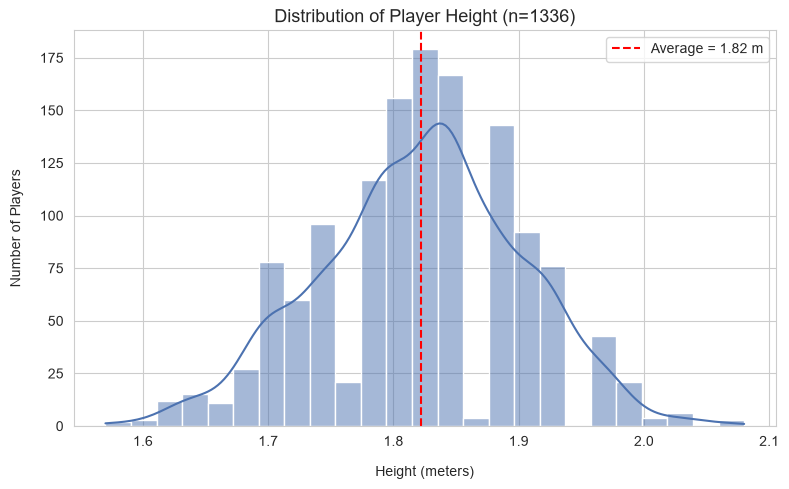

In [68]:
plt.figure(figsize=(8, 5))
sns.histplot(all_players['height'].dropna(), bins=25, color='#4C72B0', kde=True)
plt.axvline(avg_height, color='red', linestyle='--', linewidth=1.5,
            label=f'Average = {avg_height:.2f} m')
plt.title(f'Distribution of Player Height (n={valid_height_count})', fontsize=13)
plt.xlabel('Height (meters)', labelpad=12)
plt.ylabel('Number of Players', labelpad=12)
plt.legend()
plt.tight_layout()
plt.savefig('question_2_height_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Question 3
**Which player has the highest number of wins?**

In [69]:
event_clean = event_df[event_df['winner_code'].isin([1, 2])]
event_clean = event_clean[['match_id', 'winner_code']]
print('Matches with valid result:', len(event_clean))

Matches with valid result: 16266


In [70]:
home_clean = home_team[['match_id', 'player_id', 'full_name']].copy()
home_clean = home_clean.rename(columns={'player_id': 'home_pid', 'full_name': 'home_name'})

away_clean = away_team[['match_id', 'player_id', 'full_name']].copy()
away_clean = away_clean.rename(columns={'player_id': 'away_pid', 'full_name': 'away_name'})

merged = event_clean.merge(home_clean, on='match_id', how='left')
merged = merged.merge(away_clean, on='match_id', how='left')
print('Shape after merge:', merged.shape)

Shape after merge: (16266, 6)


In [71]:
home_win_matches = merged[merged['winner_code'] == 1].dropna(subset=['home_pid'])
home_wins = home_win_matches.groupby(['home_pid', 'home_name']).size().reset_index(name='wins')
home_wins = home_wins.rename(columns={'home_pid': 'player_id', 'home_name': 'name'})

away_win_matches = merged[merged['winner_code'] == 2].dropna(subset=['away_pid'])
away_wins = away_win_matches.groupby(['away_pid', 'away_name']).size().reset_index(name='wins')
away_wins = away_wins.rename(columns={'away_pid': 'player_id', 'away_name': 'name'})

all_wins   = pd.concat([home_wins, away_wins], ignore_index=True)
total_wins = all_wins.groupby(['player_id', 'name'])['wins'].sum().reset_index()
total_wins = total_wins.sort_values(['wins', 'player_id'], ascending=[False, True]).reset_index(drop=True)

print('\n Top Ten Players \n')
print(total_wins.head(10))

top = total_wins.iloc[0]
print('\nOVERALL ANSWER: \n')
print(f'Player with most wins: {top["name"]}')
print(f'Player ID : {int(top["player_id"])}')
print(f'Number of wins : {int(top["wins"])}')


 Top Ten Players 

   player_id                    name  wins
0    50901.0           Popko, Dmitry    30
1   230049.0   Jianu, Filip Cristian    23
2   231620.0        Chidekh, Clement    23
3   341818.0            Faria, Jaime    22
4   152766.0           Helgo, Malene    21
5   202572.0           Gengel, Marek    21
6   100093.0      Ferrari, Francesco    20
7   205282.0       Kužmová, Katarína    20
8   238867.0   Ovcharenko, Oleksandr    20
9   338890.0  Merida Aguilar, Daniel    20

OVERALL ANSWER: 

Player with most wins: Popko, Dmitry
Player ID : 50901
Number of wins : 30


## Question 4
**What is the longest match recorded in terms of duration?**

### Match Time Cleaning Strategy
Some matches were interrupted and logged in separate sessions. Three tests determine if duplicates are corrupt data or a valid interrupted match:

- **Test 1:** Period values across rows are identical → corrupt duplicate → remove.
- **Test 2:** Two rows share a value for the same set column → overlapping data → remove.
- **Test 3:** Timestamps must differ for a real interrupted match → merge rows into one.

In [72]:
MIN_SET_SECONDS = 10 * 60
MAX_SET_SECONDS = 150 * 60
MIN_MATCH_SECONDS = 30 * 60
MAX_MATCH_SECONDS = 420 * 60
period_columns = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']

match_time_clean = match_time_df.copy()
total_original = len(match_time_clean)

In [73]:
match_time_clean = match_time_clean.drop_duplicates()

single_rows   = match_time_clean[~match_time_clean['match_id'].duplicated(keep=False)].copy()
duplicate_ids = match_time_clean[match_time_clean['match_id'].duplicated(keep=False)].copy()

fixed_interrupted = []
corrupt_match_ids = []

for match_id, group in duplicate_ids.groupby('match_id'):
    numeric_cols  = [c for c in period_columns if c in group.columns]
    period_values = group[numeric_cols].fillna(-1)
    if (period_values.nunique() == 1).all():
        corrupt_match_ids.append(match_id)
        continue
    conflict = any(len(group[col].dropna()) > 1 for col in period_columns)
    if conflict:
        corrupt_match_ids.append(match_id)
        continue
    if 'current_period_start_timestamp' in group.columns:
        if len(group['current_period_start_timestamp'].dropna().unique()) <= 1:
            corrupt_match_ids.append(match_id)
            continue
    merged_row = {'match_id': match_id}
    for col in period_columns:
        non_null = group[col].dropna()
        merged_row[col] = non_null.iloc[0] if len(non_null) > 0 else np.nan
    if 'current_period_start_timestamp' in group.columns:
        merged_row['current_period_start_timestamp'] = (
            group['current_period_start_timestamp'].dropna().min())
    fixed_interrupted.append(merged_row)

interrupted_df = pd.DataFrame(fixed_interrupted) if fixed_interrupted else pd.DataFrame()
match_time_clean = pd.concat([single_rows, interrupted_df], ignore_index=True)
n_corrupt = len(corrupt_match_ids)
n_interrupted = len(fixed_interrupted)

In [74]:
for col in period_columns:
    bad = match_time_clean[col].notna() & (
        (match_time_clean[col] < MIN_SET_SECONDS) | (match_time_clean[col] > MAX_SET_SECONDS))
    match_time_clean.loc[bad, col] = np.nan

# Remove matches missing both the first and second set
match_time_clean = match_time_clean[
    match_time_clean['period_1'].notna() & match_time_clean['period_2'].notna()]

# logical set order: period_4 cannot exist without period_3, etc.
mask_no_p3 = match_time_clean['period_3'].isna()
match_time_clean.loc[mask_no_p3, ['period_4', 'period_5']] = np.nan
mask_no_p4 = match_time_clean['period_4'].isna()
match_time_clean.loc[mask_no_p4, 'period_5'] = np.nan

In [75]:
match_time_clean['total_seconds'] = match_time_clean[period_columns].fillna(0).sum(axis=1)
match_time_clean['total_minutes'] = (match_time_clean['total_seconds'] / 60).round(1)
match_time_clean['total_hours']   = (match_time_clean['total_seconds'] / 3600).round(2)

match_time_clean = match_time_clean[
    (match_time_clean['total_seconds'] >= MIN_MATCH_SECONDS) &
    (match_time_clean['total_seconds'] <= MAX_MATCH_SECONDS)]

total_clean = len(match_time_clean)
print('\n DATA CLEANING REPORT\n')
print(f'  Original rows : {total_original:,}')
print(f'  Corrupt duplicates removed: {n_corrupt:,} match groups')
print(f'  Interrupted matches merged: {n_interrupted:,}')
print(f'  Rows after cleaning : {total_clean:,}')


 DATA CLEANING REPORT

  Original rows : 35,671
  Corrupt duplicates removed: 1,848 match groups
  Interrupted matches merged: 91
  Rows after cleaning : 9,069


In [76]:
top_10 = (match_time_clean[['match_id', 'total_seconds', 'total_minutes', 'total_hours']]
          .sort_values('total_seconds', ascending=False).head(10))
print('TOP 10 LONGEST MATCHES:')
print(top_10.to_string(index=False))

longest = match_time_clean.loc[match_time_clean['total_seconds'].idxmax()]
print(f'\nLongest match ID : {longest["match_id"]}')
print(f'Duration : {longest["total_minutes"]} min ({longest["total_hours"]} hrs)')

TOP 10 LONGEST MATCHES:
 match_id  total_seconds  total_minutes  total_hours
 12160369        18123.0          302.0         5.03
 12056393        17834.0          297.2         4.95
 12174579        16359.0          272.6         4.54
 12201395        15929.0          265.5         4.42
 12152568        15649.0          260.8         4.35
 12163362        15505.0          258.4         4.31
 12194966        15240.0          254.0         4.23
 12063596        14922.0          248.7         4.14
 12172227        14766.0          246.1         4.10
 12159529        14737.0          245.6         4.09

Longest match ID : 12160369.0
Duration : 302.0 min (5.03 hrs)


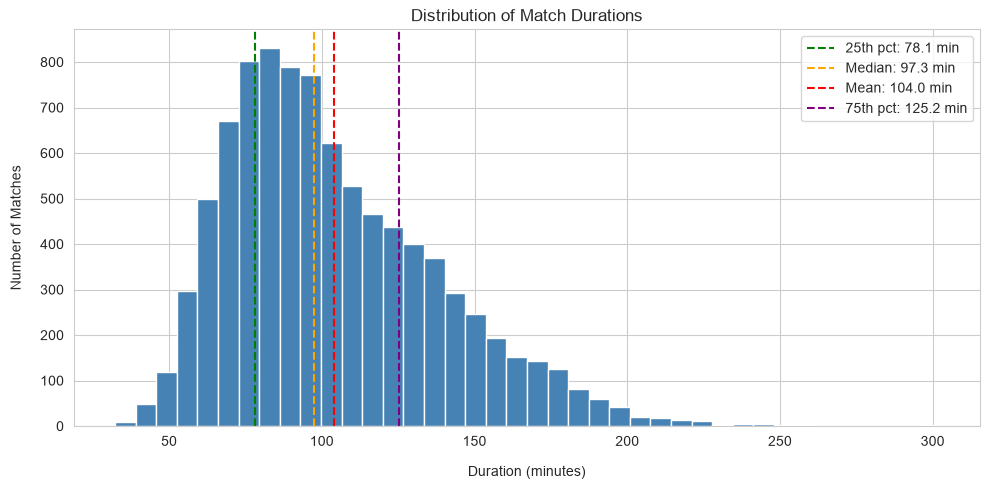

In [77]:
durations = match_time_clean['total_minutes']
q25 = durations.quantile(0.25)
q75 = durations.quantile(0.75)
mean = durations.mean()
median = durations.median()

plt.figure(figsize=(10, 5))
plt.hist(durations, bins=40, color='steelblue', edgecolor='white')
plt.axvline(q25, color='green', linestyle='--', label=f'25th pct: {q25:.1f} min')
plt.axvline(median, color='orange', linestyle='--', label=f'Median: {median:.1f} min')
plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.1f} min')
plt.axvline(q75, color='purple', linestyle='--', label=f'75th pct: {q75:.1f} min')
plt.title('Distribution of Match Durations')
plt.xlabel('Duration (minutes)', labelpad=12)
plt.ylabel('Number of Matches', labelpad=12)
plt.legend()
plt.tight_layout()
plt.savefig('question_4_match_duration_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

Most tennis matches last between 78 and 125 minutes, with an average of about 104 minutes. A small number of very long matches pull the mean slightly above the median.

## Question 5
**How many sets are typically played in a tennis match?**

In [78]:
period_cols = ['period_1', 'period_2', 'period_3', 'period_4', 'period_5']

home_score_copy = home_score.copy()
away_score_copy = away_score.copy()

home_score_copy['sets_home'] = home_score_copy[period_cols].notna().sum(axis=1)
away_score_copy['sets_away'] = away_score_copy[period_cols].notna().sum(axis=1)

merged_sets = home_score_copy[['match_id', 'sets_home']].merge(
    away_score_copy[['match_id', 'sets_away']], on='match_id', how='inner')

merged_sets['sets_played'] = merged_sets[['sets_home', 'sets_away']].max(axis=1)

# Drop walkovers or incomplete records
valid_sets = merged_sets[merged_sets['sets_played'] >= 2]

avg_sets    = valid_sets['sets_played'].mean()
median_sets = valid_sets['sets_played'].median()
mode_sets   = valid_sets['sets_played'].mode()[0]

print('Total valid matches:', len(valid_sets))
print('\n Sets Played Distribution\n')
print(valid_sets['sets_played'].value_counts().sort_index())
print(f'\nAverage sets = {avg_sets:.2f}, median = {median_sets}, most common = {mode_sets}')

Total valid matches: 14395

 Sets Played Distribution

sets_played
2    10397
3     3998
Name: count, dtype: int64

Average sets = 2.28, median = 2.0, most common = 2


- Only about a quarter of matches are competitive enough to reach a deciding third set.

## Question 6
**Which country has produced the most successful tennis players?**

A quality-weighted scoring system is used: upset wins and bigger tournaments are weighted more heavily.

In [79]:
# MAX_RANK, MIN_RANK = 2000, 1
DEFAULT_TOURN_POINTS = 1

event = event_df.copy()
event = event[event['winner_code'].isin([1, 2])]
if 'final_result_only' in event.columns:
    event = event[event['final_result_only'] != True]
print(f'Valid finished matches: {len(event)}')

home = home_team.copy()
away = away_team.copy()
home['current_rank'] = pd.to_numeric(home['current_rank'], errors='coerce')
away['current_rank'] = pd.to_numeric(away['current_rank'], errors='coerce')
for df_ in [home, away]:
    # bad = df_['current_rank'].isna() | (df_['current_rank'] < MIN_RANK) | (df_['current_rank'] > MAX_RANK)
    # df_.loc[bad, 'current_rank'] = np.nan
    df_['country'] = df_['country'].astype(str).str.strip().str.upper()
    df_.loc[df_['country'].isin(['', 'N/A', 'NA', 'NONE', 'UNKNOWN', 'NAN']), 'country'] = np.nan

m = event[['match_id', 'winner_code']].merge(
    home[['match_id', 'player_id', 'current_rank', 'country']].rename(
        columns={'player_id': 'home_pid', 'current_rank': 'home_rank', 'country': 'home_country'}),
    on='match_id', how='inner').merge(
    away[['match_id', 'player_id', 'current_rank', 'country']].rename(
        columns={'player_id': 'away_pid', 'current_rank': 'away_rank', 'country': 'away_country'}),
    on='match_id', how='inner')
m = m[m['home_pid'] != m['away_pid']]
m = m.dropna(subset=['home_rank', 'away_rank', 'home_country', 'away_country'])
print(f'Matches after filters: {len(m)}')

tourn = tournament_df[['match_id', 'tennis_points']].copy()
tourn['tennis_points'] = pd.to_numeric(tourn['tennis_points'], errors='coerce')
tourn.loc[tourn['tennis_points'] < 0, 'tennis_points'] = np.nan
tourn['tennis_points'] = tourn['tennis_points'].clip(lower=1).fillna(DEFAULT_TOURN_POINTS)
m = m.merge(tourn, on='match_id', how='left')
m['tennis_points'] = m['tennis_points'].fillna(DEFAULT_TOURN_POINTS)

# Calculate upset_factor and match_score
m['winner_rank'] = np.where(m['winner_code'] == 1, m['home_rank'], m['away_rank'])
m['loser_rank'] = np.where(m['winner_code'] == 1, m['away_rank'], m['home_rank'])
m['winner_country'] = np.where(m['winner_code'] == 1, m['home_country'], m['away_country'])
m['winner_pid'] = np.where(m['winner_code'] == 1, m['home_pid'], m['away_pid'])
m['upset_factor'] = m['winner_rank'] / m['loser_rank']
m['match_score'] = np.log1p(m['upset_factor']) * np.log1p(m['tennis_points'])

player_scores = m.groupby(['winner_pid', 'winner_country']).agg(
    total_score=('match_score', 'sum'), total_wins=('match_id', 'count'),
    upset_wins=('upset_factor', lambda x: (x > 1).sum())).reset_index()

country_scores = player_scores.groupby('winner_country').agg(
    total_score=('total_score', 'sum'), total_wins=('total_wins', 'sum'),
    upset_wins=('upset_wins', 'sum'),
    active_players=('winner_pid', 'nunique')).reset_index().sort_values('total_score', ascending=False)

print('\nTop 10 countries:')
print(country_scores.head(10).to_string(index=False))

top = country_scores.iloc[0]
print('\nOVERALL ANSWER\n')
print(f'Most successful country: {top["winner_country"]}')
print(f'Total wins             : {int(top["total_wins"])}')
print(f'Upset wins             : {int(top["upset_wins"])}')
print(f'Quality-weighted score : {top["total_score"]:.1f}')

Valid finished matches: 15150
Matches after filters: 9135

Top 10 countries:
winner_country  total_score  total_wins  upset_wins  active_players
           USA  1271.668080         755         300             167
        FRANCE   810.059476         820         287             158
         ITALY   685.244935         656         237             160
        RUSSIA   631.257768         498         180             109
     ARGENTINA   541.613508         409         135              81
       GERMANY   439.347624         418         156             100
     AUSTRALIA   427.750455         359         112              72
CZECH REPUBLIC   397.580754         304         104              55
         SPAIN   395.685230         397         155              83
         JAPAN   370.857150         375         137              93

OVERALL ANSWER

Most successful country: USA
Total wins             : 755
Upset wins             : 300
Quality-weighted score : 1271.7


## Question 7
**What is the average number of aces per match?**

In [80]:
print('Unique periods:', stats_df['period'].unique())

aces_df = stats_df[stats_df['statistic_name'] == 'aces']
print('All aces rows:', len(aces_df))
print('\nAces rows by period:')
print(aces_df['period'].value_counts())

# Check: does each match_id have exactly one row with period='ALL'?
aces_all = aces_df[aces_df['period'] == 'ALL']
print('\nRows with period=ALL:', len(aces_all))
print('Unique match_ids:', aces_all['match_id'].nunique())
print('Duplicated match_ids:', aces_all['match_id'].duplicated().sum())

Unique periods: <ArrowStringArray>
['ALL', '1ST', '2ND', '3RD']
Length: 4, dtype: str
All aces rows: 76257

Aces rows by period:
period
ALL    23283
1ST    23197
2ND    22823
3RD     6954
Name: count, dtype: int64

Rows with period=ALL: 23283
Unique match_ids: 11389
Duplicated match_ids: 11894


In [81]:
df_aces = stats_df[(stats_df['statistic_name'] == 'aces') & (stats_df['period'] == 'ALL')]
df_aces = df_aces[['match_id', 'home_value', 'away_value']].drop_duplicates()

match_counts = df_aces['match_id'].value_counts()
good_ids = match_counts[match_counts == 1].index
df_aces_clean = df_aces[df_aces['match_id'].isin(good_ids)].copy()

df_aces_clean['total_aces'] = df_aces_clean['home_value'] + df_aces_clean['away_value']

avg_per_match = df_aces_clean['total_aces'].mean()
median_per_match = df_aces_clean['total_aces'].median()

print('\n Total aces per match \n')
print(df_aces_clean['total_aces'].describe())
print(f'\nAverage aces per match = {avg_per_match:.2f}, median = {median_per_match}')


 Total aces per match 

count    10263.000000
mean         5.351067
std          5.304342
min          0.000000
25%          2.000000
50%          4.000000
75%          8.000000
max         51.000000
Name: total_aces, dtype: float64

Average aces per match = 5.35, median = 4.0


Most matches have a moderate number of aces, while a small number of serve-dominant matches with very high ace counts pull the average upward.

## Question 8
**Is there a difference in the number of double faults based on gender?**

In [82]:
df_dfaults = stats_df[(stats_df['statistic_name'] == 'double_faults') & (stats_df['period'] == 'ALL')]
df_dfaults = df_dfaults[['match_id', 'home_value', 'away_value']].drop_duplicates()

match_counts = df_dfaults['match_id'].value_counts()
good_ids = match_counts[match_counts == 1].index
df_dfaults_clean = df_dfaults[df_dfaults['match_id'].isin(good_ids)]

In [83]:
home_g = home_team[['match_id', 'gender']].rename(columns={'gender': 'home_gender'})
away_g = away_team[['match_id', 'gender']].rename(columns={'gender': 'away_gender'})

gender_df = home_g.merge(away_g, on='match_id', how='inner')
gender_df = gender_df.dropna(subset=['home_gender', 'away_gender'])
gender_df = gender_df[gender_df['home_gender'] == gender_df['away_gender']]
print('Clean gender rows:', len(gender_df))

Clean gender rows: 9858


In [84]:
merged_df = df_dfaults_clean.merge(gender_df, on='match_id', how='inner')
print('Shape after merge:', merged_df.shape)

Shape after merge: (8059, 5)


In [85]:
home_rows = merged_df[['match_id', 'home_gender', 'home_value']].rename(
    columns={'home_gender': 'gender', 'home_value': 'double_faults'})
away_rows = merged_df[['match_id', 'away_gender', 'away_value']].rename(
    columns={'away_gender': 'gender', 'away_value': 'double_faults'})

player_matches = pd.concat([home_rows, away_rows], ignore_index=True)

summary = player_matches.groupby('gender')['double_faults'].agg(['count', 'mean', 'median', 'std'])
print('\n Double Faults by Gender \n')
print(summary)

avg_men = player_matches.loc[player_matches['gender'] == 'M', 'double_faults'].mean()
avg_women = player_matches.loc[player_matches['gender'] == 'F', 'double_faults'].mean()
diff = avg_women - avg_men
print(f'\nMen avg : {avg_men:.2f}')
print(f'Women avg : {avg_women:.2f}')
print(f'Difference : {diff:.2f} ({diff/avg_men*100:.1f}% higher for women)')


 Double Faults by Gender 

        count      mean  median       std
gender                                   
F        7046  3.531791     3.0  2.765815
M        9072  2.710979     2.0  2.226215

Men avg : 2.71
Women avg : 3.53
Difference : 0.82 (30.3% higher for women)


C:\Users\User\AppData\Local\Temp\ipykernel_25216\2133921502.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=gender_summary.values, palette=['#4C72B0', '#DD8452'])


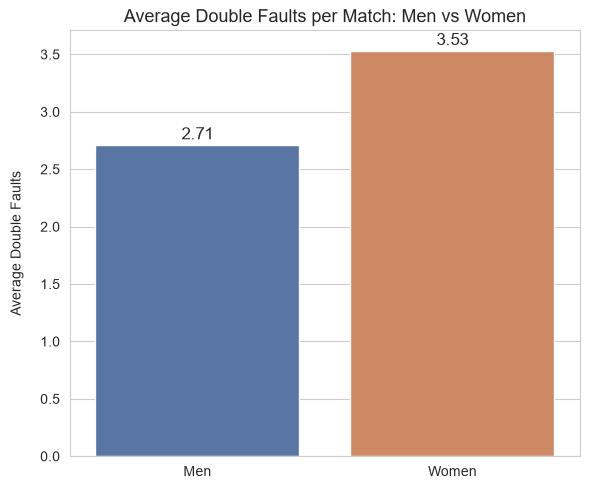

In [86]:
gender_summary = player_matches.groupby('gender')['double_faults'].mean().reindex(['M', 'F'])
labels = ['Men', 'Women']

plt.figure(figsize=(6, 5))
ax = sns.barplot(x=labels, y=gender_summary.values, palette=['#4C72B0', '#DD8452'])
for i, v in enumerate(gender_summary.values):
    ax.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=12)
plt.title('Average Double Faults per Match: Men vs Women', fontsize=13)
plt.ylabel('Average Double Faults', labelpad=12)
plt.tight_layout()
plt.savefig('question_8_double_faults_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

On average, female players commit more double faults per match than male players.

## Question 9
**Which player has won the most tournaments in a single month?**

In [87]:
event_q9 = event_df[['match_id', 'winner_code', 'start_datetime']].dropna(subset=['winner_code'])
home_q9 = home_team[['match_id', 'player_id', 'full_name']]
away_q9 = away_team[['match_id', 'player_id', 'full_name']]

# finals_df was built in the cleaning block
finals_merged = finals_df[['match_id']].merge(event_q9, on='match_id', how='inner')
finals_merged = finals_merged.merge(home_q9, on='match_id', how='inner')
finals_merged = finals_merged.merge(away_q9, on='match_id', how='inner',
                                    suffixes=('_home', '_away'))
print('Finals with complete info:', len(finals_merged))

Finals with complete info: 250


In [88]:
finals_merged['winner_id']   = np.where(finals_merged['winner_code'] == 1,
                                         finals_merged['player_id_home'],
                                         finals_merged['player_id_away'])
finals_merged['winner_name'] = np.where(finals_merged['winner_code'] == 1,
                                         finals_merged['full_name_home'],
                                         finals_merged['full_name_away'])

# Convert start_datetime (Unix timestamp in seconds since 1970) to a real date
finals_merged['match_date'] = pd.to_datetime(finals_merged['start_datetime'], unit='s')
finals_merged['year_month'] = finals_merged['match_date'].dt.to_period('M')

champion_month_counts = (
    finals_merged
    .groupby(['winner_id', 'winner_name', 'year_month'])
    .size().reset_index(name='titles')
    .sort_values('titles', ascending=False))

print(champion_month_counts.head(10))

     winner_id            winner_name year_month  titles
14       50901          Popko, Dmitry    2024-02       3
76      152766          Helgo, Malene    2024-03       3
107     202572          Gengel, Marek    2024-02       3
196     372311           Nicod, Jakub    2024-03       3
188     341818           Faria, Jaime    2024-03       3
135     230049  Jianu, Filip Cristian    2024-03       3
63      129534   Hrunčákova, Viktória    2024-03       2
22       58369             Bolt, Alex    2024-03       2
40       79467           Jasika, Omar    2024-02       2
58      111857            Ursu, Vadym    2024-03       2


In [89]:
top_row = champion_month_counts.iloc[0]

players_country = pd.concat([
    home_team[['player_id', 'country']],
    away_team[['player_id', 'country']]
], ignore_index=True).drop_duplicates(subset='player_id')

country_row    = players_country[players_country['player_id'] == top_row['winner_id']]
winner_country = country_row['country'].values[0] if len(country_row) > 0 else 'Unknown'

winner_finals = finals_merged[
    (finals_merged['winner_id']  == top_row['winner_id']) &
    (finals_merged['year_month'] == top_row['year_month'])]

winner_with_tourney = winner_finals.merge(
    tournament_df[['match_id', 'tournament_name']], on='match_id', how='left')
tourney_list = winner_with_tourney['tournament_name'].dropna().tolist()

print('\nOVERALL ANSWER\n')
print(f'Player : {top_row["winner_name"]}')
print(f'Country : {winner_country}')
print(f'Month : {top_row["year_month"]}')
print(f'Titles : {top_row["titles"]}')
print(f'tournaments: {", ".join(tourney_list)}')


OVERALL ANSWER

Player : Popko, Dmitry
Country : Kazakhstan
Month : 2024-02
Titles : 3
tournaments: Sunrise, Singles Main, M-ITF-USA-03A, Palm Coast, Singles Main, M-ITF-USA-04A, Naples, Singles Main, M-ITF-USA-05A


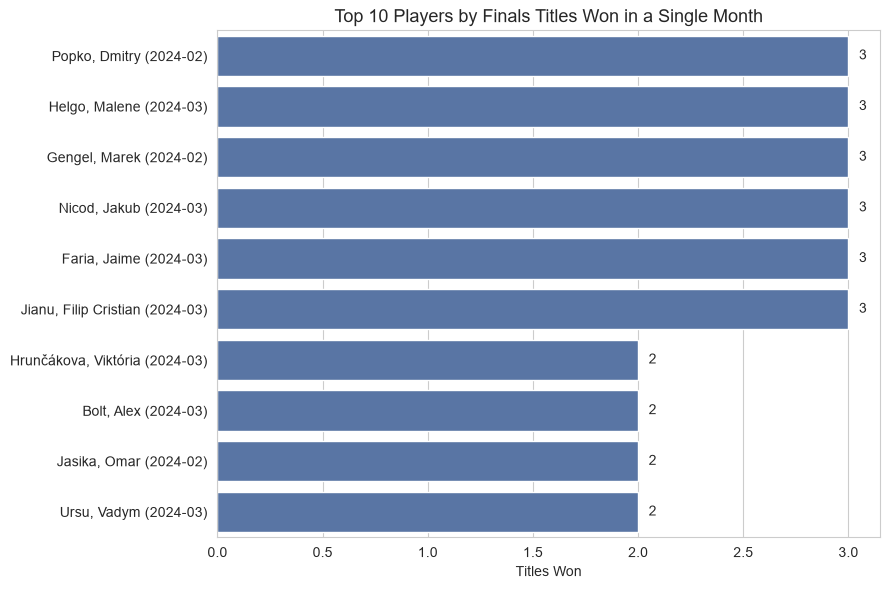

In [90]:
top10_champ = champion_month_counts.head(10).copy()
top10_champ['label'] = (top10_champ['winner_name'] + ' (' +
                        top10_champ['year_month'].astype(str) + ')')

plt.figure(figsize=(9, 6))
ax = sns.barplot(x='titles', y='label', data=top10_champ, color='#4C72B0')
for i, v in enumerate(top10_champ['titles']):
    ax.text(v + 0.05, i, str(v), va='center', fontsize=10)
plt.title('Top 10 Players by Finals Titles Won in a Single Month', fontsize=13)
plt.xlabel('Titles Won')
plt.ylabel('')
plt.tight_layout()
plt.savefig('question_9_titles_per_month.png', dpi=300, bbox_inches='tight')
plt.show()

## Question 10
**Is there a correlation between a player's height and their ranking?**

In [91]:
cols = ['player_id', 'name', 'height', 'current_rank', 'gender', 'country']
players_raw = pd.concat([home_team[cols], away_team[cols]], ignore_index=True)
print(f'Total rows before dedup: {len(players_raw)}')

players_raw = players_raw.assign(_nulls=players_raw.isnull().sum(axis=1))
players = players_raw.sort_values('_nulls').drop_duplicates(subset='player_id', keep='first')
players = players.drop(columns='_nulls').reset_index(drop=True)
print(f'Unique players: {len(players)}')

players = players.dropna(subset=['height', 'current_rank'])

overall_corr = players['height'].corr(players['current_rank'])

gender_results = {}
for g in players['gender'].dropna().unique():
    sub = players[players['gender'] == g]
    gender_results[g] = {'corr': sub['height'].corr(sub['current_rank']), 'n': len(sub)}

abs_corr = abs(overall_corr)
strength = ('negligible' if abs_corr < 0.1 else
             'weak'       if abs_corr < 0.3 else
             'moderate'   if abs_corr < 0.5 else 'strong')
direction = 'positive' if overall_corr > 0 else 'negative'

print('\nOVERALL ANSWER')
print(f'Players analyzed: {len(players)}')
print(f'Correlation (r) : {overall_corr:.4f}')
print(f'Direction : {direction}')
print(f'Strength : {strength}')
for g, r in gender_results.items():
    print(f'  {g}: r={r["corr"]:.4f} (n={r["n"]})')

q10_clean = players[['player_id', 'name', 'height', 'current_rank', 'gender', 'country']]

Total rows before dedup: 24079
Unique players: 2644

OVERALL ANSWER
Players analyzed: 1340
Correlation (r) : 0.1080
Direction : positive
Strength : weak
  F: r=-0.1847 (n=253)
  M: r=-0.1091 (n=1086)


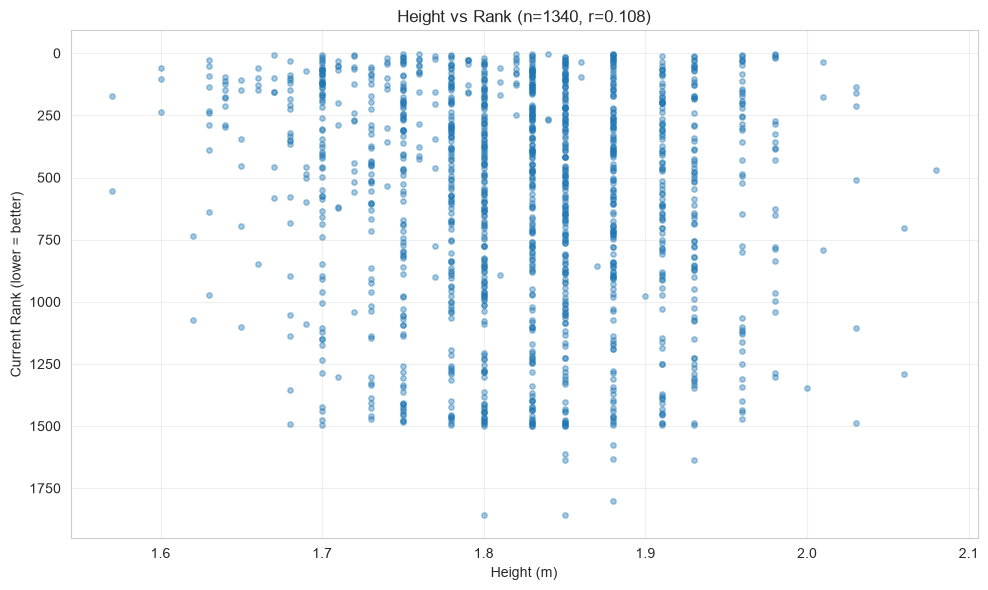

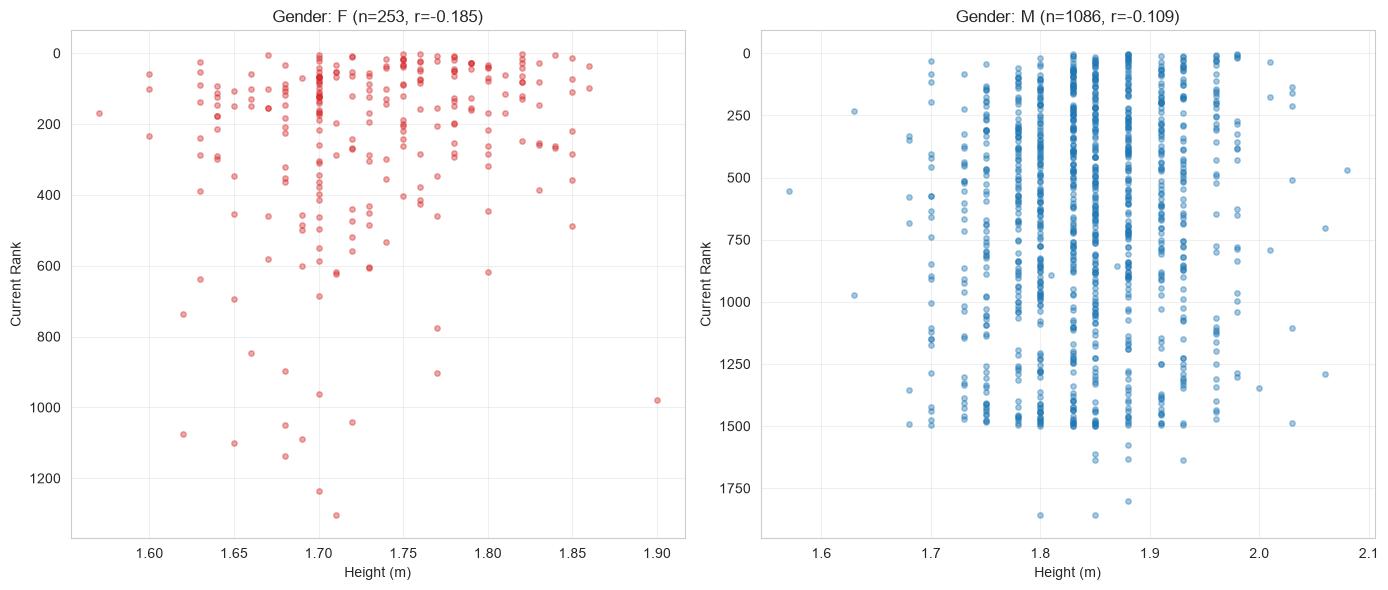

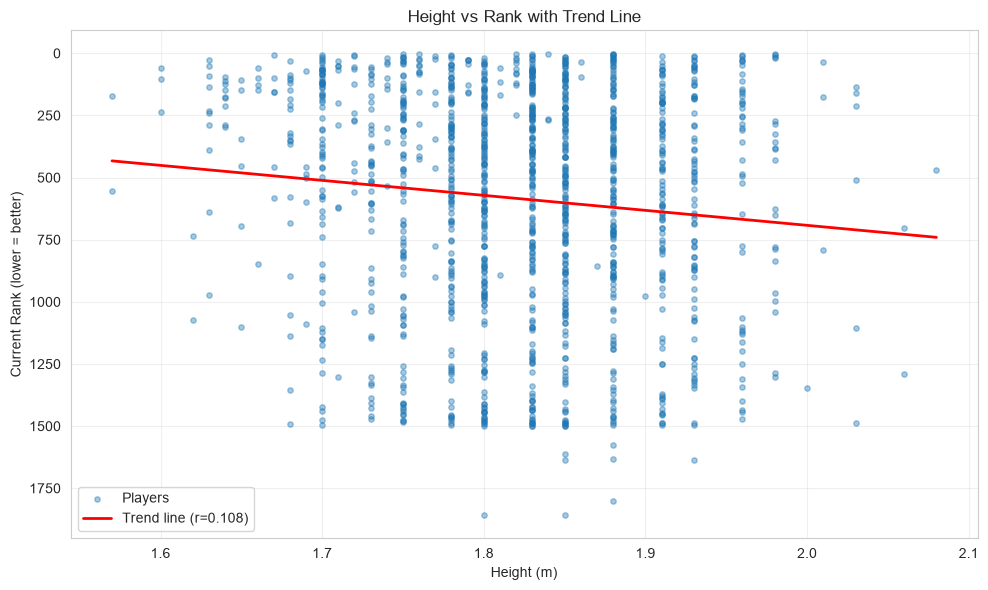

In [92]:
plt.figure(figsize=(10, 6))
plt.scatter(players['height'], players['current_rank'], alpha=0.4, s=15)
plt.xlabel('Height (m)')
plt.ylabel('Current Rank (lower = better)')
plt.title(f'Height vs Rank (n={len(players)}, r={overall_corr:.3f})')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('height_vs_rank_overall.png', dpi=300, bbox_inches='tight')
plt.show()

genders  = players['gender'].dropna().unique()
fig, axes = plt.subplots(1, len(genders), figsize=(7 * len(genders), 6))
if len(genders) == 1:
    axes = [axes]
for ax, g in zip(axes, genders):
    sub    = players[players['gender'] == g]
    corr_g = sub['height'].corr(sub['current_rank'])
    ax.scatter(sub['height'], sub['current_rank'], alpha=0.4, s=15,
               color='tab:blue' if g == 'M' else 'tab:red')
    ax.set_xlabel('Height (m)')
    ax.set_ylabel('Current Rank')
    ax.set_title(f'Gender: {g} (n={len(sub)}, r={corr_g:.3f})')
    ax.invert_yaxis()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('height_vs_rank_by_gender.png', dpi=300, bbox_inches='tight')
plt.show()

z          = np.polyfit(players['height'], players['current_rank'], 1)
trend_line = np.poly1d(z)
x_range    = np.linspace(players['height'].min(), players['height'].max(), 100)
plt.figure(figsize=(10, 6))
plt.scatter(players['height'], players['current_rank'], alpha=0.4, s=15, label='Players')
plt.plot(x_range, trend_line(x_range), color='red', linewidth=2,
         label=f'Trend line (r={overall_corr:.3f})')
plt.xlabel('Height (m)')
plt.ylabel('Current Rank (lower = better)')
plt.title('Height vs Rank with Trend Line')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('height_vs_rank_trendline.png', dpi=300, bbox_inches='tight')
plt.show()

## Question 11
**What is the average duration of matches?**

Continues directly from Question 4, using the cleaned `match_time_clean` dataframe.

In [93]:
average_duration = match_time_clean['total_seconds'].mean()
average_minutes = average_duration / 60
average_hours = average_duration / 3600

print('\nAVERAGE MATCH DURATION:')
print(f'  {average_minutes:.1f} minutes  ({average_hours:.2f} hours)')


AVERAGE MATCH DURATION:
  104.0 minutes  (1.73 hours)


## Question 12
**What is the average number of games per set in men's matches compared to women's matches?**

In [94]:
# Convert period_1..5 to long format (one row per set) using melt
home_sets = home_score.melt(
    id_vars='match_id',
    value_vars=['period_1', 'period_2', 'period_3', 'period_4', 'period_5'],
    var_name='period_col', value_name='home_games')
home_sets['set_id'] = home_sets['period_col'].str.extract(r'(\d)').astype(int)
home_sets = home_sets.drop(columns='period_col').dropna(subset=['home_games'])
home_sets['home_games'] = pd.to_numeric(home_sets['home_games'], errors='coerce')
home_sets = home_sets.dropna(subset=['home_games'])
home_sets['home_games'] = home_sets['home_games'].astype(int)

away_sets = away_score.melt(
    id_vars='match_id',
    value_vars=['period_1', 'period_2', 'period_3', 'period_4', 'period_5'],
    var_name='period_col', value_name='away_games')
away_sets['set_id'] = away_sets['period_col'].str.extract(r'(\d)').astype(int)
away_sets = away_sets.drop(columns='period_col').dropna(subset=['away_games'])
away_sets['away_games'] = pd.to_numeric(away_sets['away_games'], errors='coerce')
away_sets = away_sets.dropna(subset=['away_games'])
away_sets['away_games'] = away_sets['away_games'].astype(int)

set_scores = home_sets.merge(away_sets, on=['match_id', 'set_id'])
set_scores['total_games'] = set_scores['home_games'] + set_scores['away_games']

In [95]:
# Validate set scores — keep only scores possible in tennis
# 6-0 to 6-4 (normal), 7-5 (extended), 7-6 (tiebreak), 1-0 (match tiebreak in last set)
h = set_scores['home_games']
a = set_scores['away_games']

standard_set = ((h == 6) & (a.between(0, 4))) | ((a == 6) & (h.between(0, 4)))
set_7_5 = ((h == 7) & (a == 5)) | ((a == 7) & (h == 5))
set_7_6 = ((h == 7) & (a == 6)) | ((a == 7) & (h == 6))

# Identify the last set for each match
last_set = set_scores.groupby('match_id')['set_id'].max().reset_index()
last_set = last_set.rename(columns={'set_id': 'last_set_id'})
set_scores = set_scores.merge(last_set, on='match_id')
is_last_set = set_scores['set_id'] == set_scores['last_set_id']
match_tiebreak = is_last_set & (((h == 1) & (a == 0)) | ((a == 1) & (h == 0)))

valid = standard_set | set_7_5 | set_7_6 | match_tiebreak
set_scores['is_valid'] = valid
set_scores['is_match_tiebreak'] = match_tiebreak

print('Sets before validation:', len(set_scores))
set_scores_valid = set_scores[set_scores['is_valid']].copy()
print('Sets after validation:', len(set_scores_valid))
print('Removed sets (impossible scores):', len(set_scores) - len(set_scores_valid))

Sets before validation: 32978
Sets after validation: 28930
Removed sets (impossible scores): 4048


In [96]:
# Cross-validate with pbp.csv
# Count actual games per set from the pbp data
# Only accept sets that appear in both the score table and play-by-play data
games_from_pbp = (pbp_df.groupby(['match_id', 'set_id'])['game_id']
                  .nunique().reset_index()
                  .rename(columns={'game_id': 'num_games_pbp'}))

final_sets = set_scores_valid.merge(games_from_pbp, on=['match_id', 'set_id'], how='inner')

In [97]:
# Add gender, only matches where both players share the same gender
home_gender = home_team[['match_id', 'gender']].dropna().copy()
home_gender['gender'] = home_gender['gender'].str.strip().str.upper()
home_gender = home_gender.rename(columns={'gender': 'home_gender'})

away_gender = away_team[['match_id', 'gender']].dropna().copy()
away_gender['gender'] = away_gender['gender'].str.strip().str.upper()
away_gender = away_gender.rename(columns={'gender': 'away_gender'})

gender_df2  = home_gender.merge(away_gender, on='match_id')
gender_df2  = gender_df2[gender_df2['home_gender'] == gender_df2['away_gender']]
gender_df2  = gender_df2[gender_df2['home_gender'].isin(['M', 'F'])]
gender_df2['gender'] = gender_df2['home_gender']
gender_df2  = gender_df2[['match_id', 'gender']]

analysis_df = final_sets.merge(gender_df2, on='match_id')
print('Total (match, set) records in final dataset:', len(analysis_df))
print('Unique matches:', analysis_df['match_id'].nunique())

Total (match, set) records in final dataset: 17525
Unique matches: 7861


In [98]:
# Average games per set by gender
# Match tiebreaks (1-game sets) are excluded because their structure is different
normal_sets = analysis_df[analysis_df['is_match_tiebreak'] == False]

result = (normal_sets.groupby('gender')['total_games']
          .agg(['mean', 'median', 'std', 'count'])
          .round(3)
          .rename(index={'M': 'Men', 'F': 'Women'}))

print('\n=== Average Number of Games per Set: Men vs Women ===')
print(result)


=== Average Number of Games per Set: Men vs Women ===
         mean  median    std  count
gender                             
Women   9.183     9.0  1.958   7719
Men     9.558     9.0  1.983   9774


## Question 13
**What is the distribution of left-handed versus right-handed players?**

In [99]:
players_hand = all_players[['player_id', 'full_name', 'plays']].copy()
print('Unique players:', len(players_hand))
print('Null plays values:', players_hand['plays'].isnull().sum())
print('\nRaw plays values ')
print(players_hand['plays'].value_counts(dropna=False))

Unique players: 2644
Null plays values: 1498

Raw plays values 
plays
NaN             1498
right-handed    1013
left-handed      133
Name: count, dtype: int64


In [100]:
players_valid = players_hand.dropna(subset=['plays'])
hand_counts = players_valid['plays'].value_counts()
hand_percent = players_valid['plays'].value_counts(normalize=True) * 100

summary_hand = pd.DataFrame({'count': hand_counts, 'percent': hand_percent.round(1)})
print('\nHandedness distribution \n')
print(summary_hand)


Handedness distribution 

              count  percent
plays                       
right-handed   1013     88.4
left-handed     133     11.6


C:\Users\User\AppData\Local\Temp\ipykernel_25216\1957533398.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=hand_counts.index, y=hand_counts.values, palette=['#4C72B0', '#DD8452'])


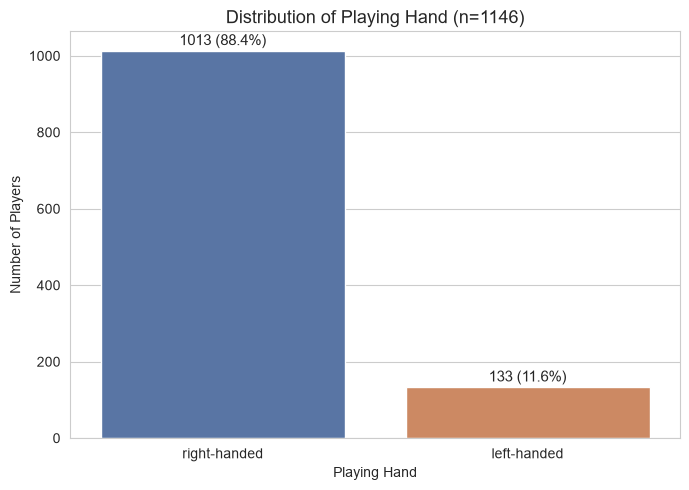

In [101]:
plt.figure(figsize=(7, 5))
ax = sns.barplot(x=hand_counts.index, y=hand_counts.values, palette=['#4C72B0', '#DD8452'])
for i, v in enumerate(hand_counts.values):
    pct = hand_percent.values[i]
    ax.text(i, v + 15, f'{v} ({pct:.1f}%)', ha='center', fontsize=11)
plt.title(f'Distribution of Playing Hand (n={len(players_valid)})', fontsize=13)
plt.xlabel('Playing Hand')
plt.ylabel('Number of Players')
plt.tight_layout()
plt.savefig('question_13_playing_hand_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Question 14
**What is the most common type of surface used in tournaments?**

In [102]:
# Check consistency of ground_type within each tournament
consistency_check = tournament_df.groupby('tournament_id')['ground_type'].nunique()
print(f'Tournaments with inconsistent ground_type: {(consistency_check > 1).sum()}')

tournament_level = tournament_df.drop_duplicates(subset='tournament_id').dropna(subset=['ground_type'])
print(f'Unique tournaments analyzed: {len(tournament_level)}')

tour_counts = tournament_level['ground_type'].value_counts()
tour_pct    = (tournament_level['ground_type'].value_counts(normalize=True) * 100).round(1)
print(pd.DataFrame({'count': tour_counts, 'pct': tour_pct}))

top_surface = tour_counts.idxmax()
print(f'\nMost common surface: {top_surface} ({tour_counts.max()} tournaments, {tour_pct.max()}%)')

Tournaments with inconsistent ground_type: 8
Unique tournaments analyzed: 527
                   count   pct
ground_type                   
Hardcourt outdoor    239  45.4
Red clay             184  34.9
Hardcourt indoor      83  15.7
Red clay indoor        6   1.1
Grass                  6   1.1
Carpet indoor          5   0.9
Synthetic outdoor      3   0.6
Green clay             1   0.2

Most common surface: Hardcourt outdoor (239 tournaments, 45.4%)


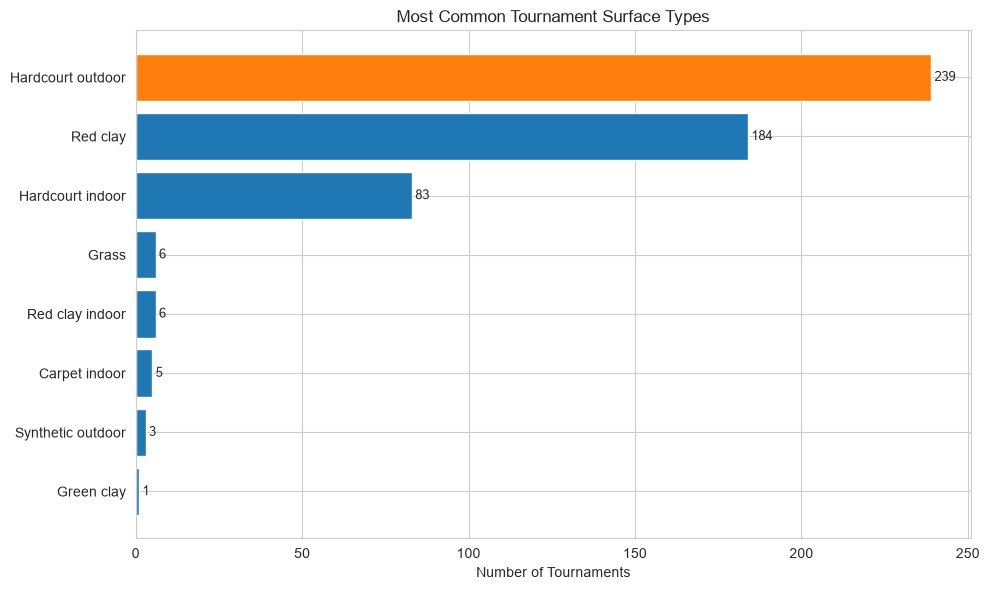

In [103]:
t_level = tournament_df.drop_duplicates(subset='tournament_id').dropna(subset=['ground_type'])
t_counts = t_level['ground_type'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['tab:orange' if v == t_counts.max() else 'tab:blue' for v in t_counts.values]
bars   = plt.barh(t_counts.index, t_counts.values, color=colors)
for bar, val in zip(bars, t_counts.values):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
             str(val), va='center', fontsize=9)
plt.xlabel('Number of Tournaments')
plt.title('Most Common Tournament Surface Types')
plt.tight_layout()
plt.savefig('question_14_surface_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Question 15
**How many distinct countries are represented in the dataset?**

In [104]:
# Player countries (home + away) as a set
home_ctry_set = set(home_team['country'].dropna().unique())
away_ctry_set = set(away_team['country'].dropna().unique())
player_ctry_set = home_ctry_set | away_ctry_set
print(f'Distinct player countries: {len(player_ctry_set)}')

# Venue countries (match locations)
venue_ctry_set  = set(venue_df['country'].dropna().unique())
print(f'Distinct venue countries: {len(venue_ctry_set)}')

# Countries that only appear as hosts, not as player nationalities
venue_only = venue_ctry_set - player_ctry_set
print(f'Host-only countries (no player from there): {len(venue_only)}')
print(sorted(venue_only))

all_countries_union = player_ctry_set | venue_ctry_set

print('\nOVERALL ANSWER\n')
print(f'Countries (players only) : {len(player_ctry_set)}')
print(f'Countries (venues only) : {len(venue_ctry_set)}')
print(f'Countries (union of both) : {len(all_countries_union)}')

Distinct player countries: 101
Distinct venue countries: 64
Host-only countries (no player from there): 7
['Bahrain', 'England', 'Rwanda', 'Scotland', 'Sri Lanka', 'Togo', 'United Arab Emirates']

OVERALL ANSWER

Countries (players only) : 101
Countries (venues only) : 64
Countries (union of both) : 108


## Question 16
**Which player has the highest winning percentage against top 10 ranked opponents?**

In [105]:
event_q16 = event_df[['match_id', 'winner_code']].copy()
home_q16 = home_team[['match_id', 'player_id', 'full_name', 'current_rank']].copy()
away_q16 = away_team[['match_id', 'player_id', 'full_name', 'current_rank']].copy()

event_q16 = event_q16.dropna(subset=['match_id', 'winner_code'])
home_q16 = home_q16.dropna(subset=['match_id', 'player_id', 'current_rank'])
away_q16 = away_q16.dropna(subset=['match_id', 'player_id', 'current_rank'])

before = len(event_q16)
event_q16 = event_q16[event_q16['winner_code'].isin([1, 2])]
print(f'Dropped {before - len(event_q16):,} rows with invalid winner_code')

Dropped 0 rows with invalid winner_code


In [106]:
df_q16 = event_q16.merge(
    home_q16.rename(columns={'player_id': 'home_player_id',
                             'full_name':   'home_full_name',
                             'current_rank':'home_rank'}),
    on='match_id', how='inner'
).merge(
    away_q16.rename(columns={'player_id': 'away_player_id',
                             'full_name':   'away_full_name',
                             'current_rank':'away_rank'}),
    on='match_id', how='inner')

before  = len(df_q16)
df_q16  = df_q16[df_q16['home_player_id'] != df_q16['away_player_id']]
print(f'Dropped {before - len(df_q16):,} where home == away player')

Dropped 0 where home == away player


In [107]:
home_view = df_q16[['match_id', 'winner_code', 'home_player_id',
                     'home_full_name', 'home_rank', 'away_rank']].copy()
home_view.columns = ['match_id', 'winner_code', 'player_id',
                     'full_name', 'current_rank', 'opponent_rank']
home_view['won'] = (home_view['winner_code'] == 1).astype(int)

away_view = df_q16[['match_id', 'winner_code', 'away_player_id',
                     'away_full_name', 'away_rank', 'home_rank']].copy()
away_view.columns = ['match_id', 'winner_code', 'player_id',
                     'full_name', 'current_rank', 'opponent_rank']
away_view['won'] = (away_view['winner_code'] == 2).astype(int)

all_matches_q16 = pd.concat([home_view, away_view], ignore_index=True)
top10_matches   = all_matches_q16[all_matches_q16['opponent_rank'] <= 10].copy()
top10_matches['full_name'] = top10_matches['full_name'].fillna(
    'Player_' + top10_matches['player_id'].astype(str))

print(f'Total matches vs top 10 opponents: {len(top10_matches):,}')

Total matches vs top 10 opponents: 234


In [108]:
stats_q16 = (
    top10_matches
    .groupby(['player_id', 'full_name'])
    .agg(current_rank=('current_rank', 'min'),
         matches_vs_top10=('won', 'count'),
         wins_vs_top10=('won', 'sum'))
    .reset_index())

stats_q16['win_pct'] = (stats_q16['wins_vs_top10'] / stats_q16['matches_vs_top10'] * 100).round(2)

MIN_MATCHES = 3
before = len(stats_q16)
stats_q16 = stats_q16[stats_q16['matches_vs_top10'] >= MIN_MATCHES]
stats_q16 = stats_q16.sort_values('win_pct', ascending=False).reset_index(drop=True)

stats_q16.columns = ['Player ID', 'Full Name', 'Current Rank',
                     'Matches vs Top 10', 'Wins vs Top 10', 'Win %']

print(f'Removed {before - len(stats_q16):,} players with fewer than {MIN_MATCHES} matches vs top 10\n')
print('Highest Win % vs Top 10 Opponents\n')
print(stats_q16.head(15).to_string(index=False))

Removed 104 players with fewer than 3 matches vs top 10

Highest Win % vs Top 10 Opponents

 Player ID              Full Name  Current Rank  Matches vs Top 10  Wins vs Top 10  Win %
    185388           Humbert, Ugo          15.0                  3               3 100.00
    228272           Swiatek, Iga           1.0                  3               3 100.00
    179146       Kalinskaya, Anna          24.0                  5               4  80.00
    206570         Sinner, Jannik           2.0                  4               3  75.00
    275923        Alcaraz, Carlos           2.0                  4               3  75.00
     89632         Jarry, Nicolas          21.0                  3               2  66.67
     19728        Cirstea, Sorana          22.0                  3               2  66.67
    230056         Kostyuk, Marta          20.0                  3               2  66.67
     23581       Dimitrov, Grigor           9.0                  5               3  60.00
    2012

C:\Users\User\AppData\Local\Temp\ipykernel_25216\390947241.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top15, x='Win %', y='Full Name', palette='Blues_r', ax=ax)


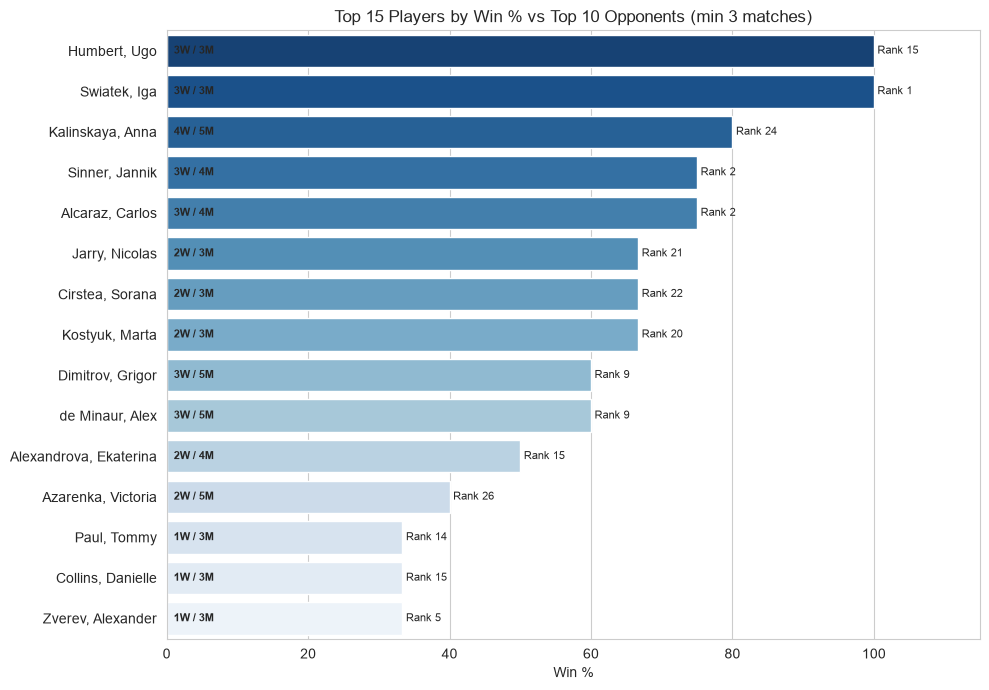

In [109]:
top15 = stats_q16.head(15).copy()

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=top15, x='Win %', y='Full Name', palette='Blues_r', ax=ax)

for i, row in top15.iterrows():
    ax.text(1, i,
            f'{int(row["Wins vs Top 10"])}W / {int(row["Matches vs Top 10"])}M',
            va='center', ha='left', fontsize=8, fontweight='bold')
for i, row in top15.iterrows():
    ax.text(row['Win %'] + 0.5, i,
            f'Rank {int(row["Current Rank"])}',
            va='center', ha='left', fontsize=8)

ax.set_title('Top 15 Players by Win % vs Top 10 Opponents (min 3 matches)')
ax.set_xlabel('Win %')
ax.set_ylabel('')
ax.set_xlim(0, 115)
plt.tight_layout()
plt.savefig('question_16_win_pct_vs_top10.png', dpi=300, bbox_inches='tight')
plt.show()

## Question 17
**What is the average number of breaks of serve per match?**

In [110]:
stats_breaks = stats_df[["match_id", "period", "statistic_name",
                          "home_value", "away_value"]].copy()

In [111]:
breaks_df = stats_breaks[stats_breaks['statistic_name'] == 'break_points_converted'].copy()
print(f'Rows with break_points_converted: {len(breaks_df):,}')

breaks_df = breaks_df[breaks_df['period'] == 'ALL']
print(f'Rows after keeping period == ALL: {len(breaks_df):,}')

breaks_df = breaks_df.dropna(subset=['match_id', 'home_value', 'away_value'])

before = len(breaks_df)
breaks_df = breaks_df[
    (breaks_df['home_value'] >= 0) & (breaks_df['away_value'] >= 0)]
print(f'Dropped {before - len(breaks_df):,} rows with negative values')

before = len(breaks_df)
breaks_df = breaks_df.drop_duplicates(subset=['match_id', 'period', 'statistic_name'])
print(f'Dropped {before - len(breaks_df):,} duplicate rows')

breaks_df = breaks_df.copy()
breaks_df['total_breaks'] = breaks_df['home_value'] + breaks_df['away_value']

avg_breaks = breaks_df['total_breaks'].mean().round(3)
med_breaks = breaks_df['total_breaks'].median()
std_breaks = breaks_df['total_breaks'].std().round(3)
total_matches = len(breaks_df)

print(f'\nTotal matches: {total_matches:,}')
print(f'Matches with 0 breaks: {(breaks_df["total_breaks"] == 0).sum():,}')
print(f'\nMean : {avg_breaks}')
print(f'Median : {med_breaks}')
print(f'Std Dev : {std_breaks}')

Rows with break_points_converted: 76,265
Rows after keeping period == ALL: 23,291
Dropped 0 rows with negative values
Dropped 11,898 duplicate rows

Total matches: 11,393
Matches with 0 breaks: 308

Mean : 6.446
Median : 6.0
Std Dev : 3.313


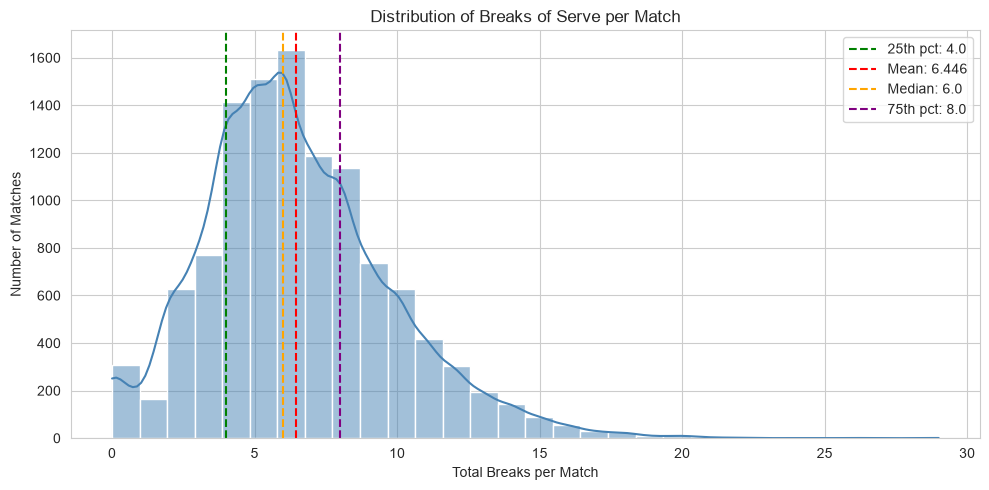

In [112]:
q25 = breaks_df['total_breaks'].quantile(0.25)
q75 = breaks_df['total_breaks'].quantile(0.75)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(breaks_df['total_breaks'], bins=30, kde=True, color='steelblue', ax=ax)
ax.axvline(q25, color='green', linestyle='--', label=f'25th pct: {q25}')
ax.axvline(avg_breaks, color='red', linestyle='--', label=f'Mean: {avg_breaks}')
ax.axvline(med_breaks, color='orange', linestyle='--', label=f'Median: {med_breaks}')
ax.axvline(q75, color='purple', linestyle='--', label=f'75th pct: {q75}')
ax.set_title('Distribution of Breaks of Serve per Match')
ax.set_xlabel('Total Breaks per Match')
ax.set_ylabel('Number of Matches')
ax.legend()
plt.tight_layout()
plt.savefig('question_17_breaks_per_match.png', dpi=300, bbox_inches='tight')
plt.show()

Most matches contain between 4 and 8 breaks of serve, with a median of 6 and a mean of 6.45. The right-skewed tail shows that while some matches exceed 15 breaks, the majority follow a consistent and predictable pattern.

---
# Exploratory Questions

### Optional Question 1
**In which player rank range were voters able to correctly predict the winner at the highest rate?**

In [113]:
votes_q = votes_df[['match_id', 'home_vote', 'away_vote']].copy()
votes_q = votes_q.dropna(subset=['match_id', 'home_vote', 'away_vote'])
votes_q = votes_q[(votes_q['home_vote'] >= 0) & (votes_q['away_vote'] >= 0)]
votes_q = votes_q[votes_q['home_vote'] + votes_q['away_vote'] > 0]
votes_q = votes_q.drop_duplicates(subset=['match_id'])
votes_q = votes_q[votes_q['home_vote'] != votes_q['away_vote']]
votes_q['voters_pick'] = np.where(votes_q['home_vote'] > votes_q['away_vote'], 1, 2)

event_opt1 = event_df[['match_id', 'winner_code']].copy()
event_opt1 = event_opt1.dropna()
event_opt1 = event_opt1[event_opt1['winner_code'].isin([1, 2])].drop_duplicates(subset=['match_id'])

home_rank_opt1 = (home_team[['match_id', 'current_rank']].dropna()
                  .query('current_rank > 0').drop_duplicates(subset=['match_id']))
away_rank_opt1 = (away_team[['match_id', 'current_rank']].dropna()
                  .query('current_rank > 0').drop_duplicates(subset=['match_id']))

match_df_opt1 = (
    votes_q
    .merge(event_opt1, on='match_id')
    .merge(home_rank_opt1.rename(columns={'current_rank': 'home_rank'}), on='match_id')
    .merge(away_rank_opt1.rename(columns={'current_rank': 'away_rank'}), on='match_id'))

match_df_opt1['voters_correct'] = (match_df_opt1['voters_pick'] == match_df_opt1['winner_code']).astype(int)
match_df_opt1['winner_rank']    = np.where(match_df_opt1['winner_code'] == 1,
                                            match_df_opt1['home_rank'], match_df_opt1['away_rank'])

Voter Prediction Accuracy by Winner Rank Range:
rank_group  total_matches  correct_guesses  correct_pct
      1-10            165              157        95.15
     11-25            206              152        73.79
     26-50            248              168        67.74
    51-100            538              371        68.96
   101-200           1135              816        71.89
   201-500           3159             2282        72.24
      500+           3844             2209        57.47


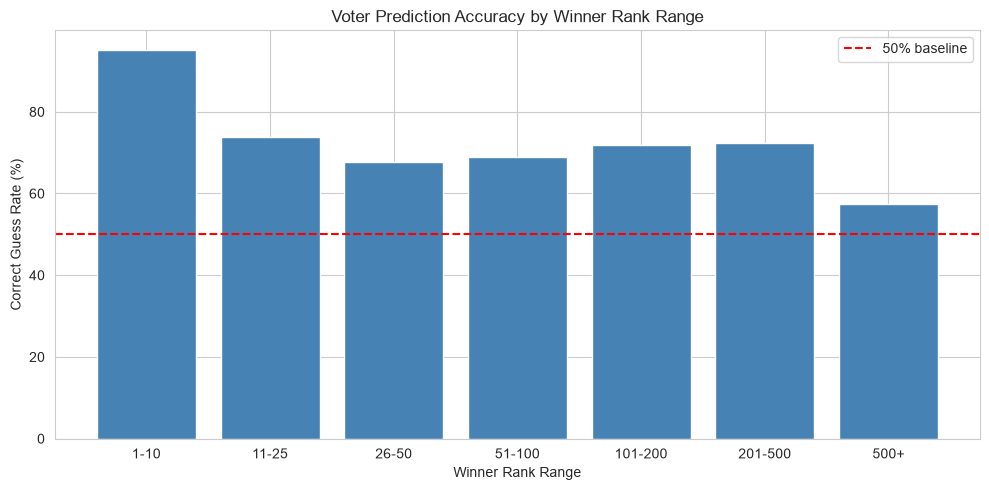

In [114]:
rank_bins = [0, 10, 25, 50, 100, 200, 500, np.inf]
rank_labels = ['1-10', '11-25', '26-50', '51-100', '101-200', '201-500', '500+']

match_df_opt1['rank_group'] = pd.cut(
    match_df_opt1['winner_rank'], bins=rank_bins, labels=rank_labels)

result_opt1 = (
    match_df_opt1.groupby('rank_group', observed=True)
    .agg(total_matches=('voters_correct', 'count'),
         correct_guesses=('voters_correct', 'sum'),
         correct_pct=('voters_correct', 'mean'))
    .reset_index())
result_opt1['correct_pct'] = (result_opt1['correct_pct'] * 100).round(2)

print('Voter Prediction Accuracy by Winner Rank Range:')
print(result_opt1.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(result_opt1['rank_group'].astype(str), result_opt1['correct_pct'],
        color='steelblue', edgecolor='white')
plt.axhline(50, color='red', linestyle='--', label='50% baseline')
plt.title('Voter Prediction Accuracy by Winner Rank Range')
plt.xlabel('Winner Rank Range')
plt.ylabel('Correct Guess Rate (%)')
plt.legend()
plt.tight_layout()
plt.savefig('optional_1_voter_accuracy_by_rank.png', dpi=300, bbox_inches='tight')
plt.show()

- Voters were most accurate when the winner was ranked **1–10**, with a correct guess rate of about **95%**. But for ranks over **10** as you can see accuracy is about the same. Which make sense, because most of the people watch the top 10 players more than the others and know them better.

### Optional Question 2
**Is there a relationship between a player's win rate and the number of different cities they have played in?**

In [115]:
venue_opt2 = venue_df[['match_id', 'city']].dropna().copy()
venue_opt2['city'] = venue_opt2['city'].str.strip().str.title()
venue_opt2 = venue_opt2[venue_opt2['city'].str.len() > 1].drop_duplicates(subset=['match_id'])

home_opt2 = home_team[['match_id', 'player_id']].dropna().drop_duplicates(subset=['match_id']).copy()
away_opt2 = away_team[['match_id', 'player_id']].dropna().drop_duplicates(subset=['match_id']).copy()

event_opt2 = event_df[['match_id', 'winner_code']].copy()
event_opt2 = event_opt2.dropna()
event_opt2 = event_opt2[event_opt2['winner_code'].isin([1, 2])].drop_duplicates(subset=['match_id'])

match_df_opt2 = (
    event_opt2
    .merge(venue_opt2, on='match_id')
    .merge(home_opt2.rename(columns={'player_id': 'home_player_id'}), on='match_id')
    .merge(away_opt2.rename(columns={'player_id': 'away_player_id'}), on='match_id'))

home_rows_opt2 = match_df_opt2[['match_id', 'home_player_id', 'city', 'winner_code']].copy()
home_rows_opt2['player_id'] = home_rows_opt2['home_player_id']
home_rows_opt2['won'] = (home_rows_opt2['winner_code'] == 1).astype(int)

away_rows_opt2 = match_df_opt2[['match_id', 'away_player_id', 'city', 'winner_code']].copy()
away_rows_opt2['player_id'] = away_rows_opt2['away_player_id']
away_rows_opt2['won'] = (away_rows_opt2['winner_code'] == 2).astype(int)

player_df_opt2 = pd.concat(
    [home_rows_opt2[['match_id', 'player_id', 'city', 'won']],
     away_rows_opt2[['match_id', 'player_id', 'city', 'won']]],
    ignore_index=True)

Win Rate by Number of Distinct Cities Played In:
city_group  total_players  avg_win_rate  median_win_rate
         1             28         59.51            60.77
         2             54         66.69            66.67
         3            109         63.45            64.29
         4            152         62.20            62.50
         5            194         57.93            57.14
         6            171         55.55            54.55
         7             89         49.51            50.00
        8+             30         47.75            42.86


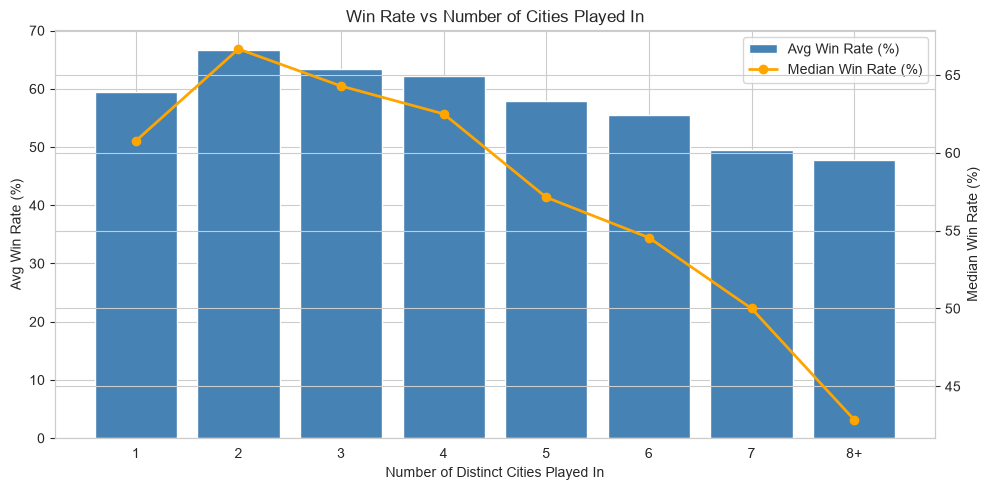

In [116]:
player_stats_opt2 = (
    player_df_opt2.groupby('player_id')
    .agg(total_matches=('won', 'count'), total_wins=('won', 'sum'),
         distinct_cities=('city', 'nunique'))
    .reset_index())
player_stats_opt2['win_rate'] = (player_stats_opt2['total_wins'] / player_stats_opt2['total_matches']).round(4)
player_stats_opt2 = player_stats_opt2[player_stats_opt2['total_matches'] >= 10]

city_bins = [0, 1, 2, 3, 4, 5, 6, 7, np.inf]
city_labels = ['1', '2', '3', '4', '5', '6', '7', '8+']
player_stats_opt2['city_group'] = pd.cut(
    player_stats_opt2['distinct_cities'], bins=city_bins, labels=city_labels)

result_opt2 = (
    player_stats_opt2.groupby('city_group', observed=True)
    .agg(total_players=('player_id', 'count'),
         avg_win_rate=('win_rate', 'mean'),
         median_win_rate=('win_rate', 'median'))
    .reset_index())
result_opt2['avg_win_rate']    = (result_opt2['avg_win_rate']    * 100).round(2)
result_opt2['median_win_rate'] = (result_opt2['median_win_rate'] * 100).round(2)

print('Win Rate by Number of Distinct Cities Played In:')
print(result_opt2.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(result_opt2['city_group'].astype(str), result_opt2['avg_win_rate'],
        color='steelblue', edgecolor='white', label='Avg Win Rate (%)')
ax1.set_xlabel('Number of Distinct Cities Played In')
ax1.set_ylabel('Avg Win Rate (%)')
ax1.set_title('Win Rate vs Number of Cities Played In')
ax2 = ax1.twinx()
ax2.plot(result_opt2['city_group'].astype(str), result_opt2['median_win_rate'],
         color='orange', marker='o', linewidth=2, label='Median Win Rate (%)')
ax2.set_ylabel('Median Win Rate (%)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig('optional_2_win_rate_vs_cities.png', dpi=300, bbox_inches='tight')
plt.show()

- Players who played in more cities generally had a lower win rate, especially after 4 cities. This may suggest that playing in more cities could be linked to travel and fatigue.


### Optional Question 3
**Is there a relationship between player rank and comeback rate?**

A comeback is defined as:
- **Type 1:** Being 2+ games behind in a set but winning that set.
- **Type 2:** Losing the first set but winning the match.

In [117]:
home_rank_opt3 = (home_team[['match_id', 'current_rank']].dropna()
                  .query('current_rank > 0').drop_duplicates(subset=['match_id']))
away_rank_opt3 = (away_team[['match_id', 'current_rank']].dropna()
                  .query('current_rank > 0').drop_duplicates(subset=['match_id']))

event_opt3 = event_df[['match_id', 'winner_code']].dropna()
event_opt3 = event_opt3[event_opt3['winner_code'].isin([1, 2])].drop_duplicates(subset=['match_id'])

last_point_per_game = (
    pbp_df
    .sort_values(['match_id', 'set_id', 'game_id', 'point_id'])
    .groupby(['match_id', 'set_id', 'game_id']).last().reset_index()
    [['match_id', 'set_id', 'game_id', 'home_score', 'away_score']])

set_game_stats = (
    last_point_per_game
    .assign(home_deficit=lambda d: d['away_score'] - d['home_score'],
            away_deficit=lambda d: d['home_score'] - d['away_score'])
    .groupby(['match_id', 'set_id'])
    .agg(max_home_deficit=('home_deficit', 'max'),
         max_away_deficit=('away_deficit', 'max'),
         final_home_games=('home_score',   'last'),
         final_away_games=('away_score',   'last'))
    .reset_index())
set_game_stats['home_won_set'] = (
    set_game_stats['final_home_games'] > set_game_stats['final_away_games'])

In [118]:
# Type 1
home_set_sit = set_game_stats.assign(
    home_in_sit   = lambda d: d['max_home_deficit'] >= 2,
    home_converted= lambda d: (d['max_home_deficit'] >= 2) & d['home_won_set'])
away_set_sit = set_game_stats.assign(
    away_in_sit   = lambda d: d['max_away_deficit'] >= 2,
    away_converted= lambda d: (d['max_away_deficit'] >= 2) & ~d['home_won_set'])

type1_home = home_set_sit.groupby('match_id').agg(
    home_t1_sit=('home_in_sit',    'sum'),
    home_t1_con=('home_converted', 'sum')).reset_index()
type1_away = away_set_sit.groupby('match_id').agg(
    away_t1_sit=('away_in_sit',    'sum'),
    away_t1_con=('away_converted', 'sum')).reset_index()

# Type 2
set_scores_opt3 = (
    home_score[['match_id', 'period_1']]
    .merge(away_score[['match_id', 'period_1']], on='match_id', suffixes=('_home', '_away'))
    .dropna(subset=['period_1_home', 'period_1_away'])
    .merge(event_opt3, on='match_id', how='inner'))

set_scores_opt3['home_t2_sit'] = (set_scores_opt3['period_1_home'] < set_scores_opt3['period_1_away']).astype(int)
set_scores_opt3['home_t2_con'] = ((set_scores_opt3['period_1_home'] < set_scores_opt3['period_1_away']) &
                                   (set_scores_opt3['winner_code'] == 1)).astype(int)
set_scores_opt3['away_t2_sit'] = (set_scores_opt3['period_1_away'] < set_scores_opt3['period_1_home']).astype(int)
set_scores_opt3['away_t2_con'] = ((set_scores_opt3['period_1_away'] < set_scores_opt3['period_1_home']) &
                                   (set_scores_opt3['winner_code'] == 2)).astype(int)

type2 = set_scores_opt3[['match_id', 'home_t2_sit', 'home_t2_con', 'away_t2_sit', 'away_t2_con']]

comebacks = (
    type1_home.merge(type1_away, on='match_id', how='outer')
    .merge(type2,           on='match_id', how='outer').fillna(0))

comebacks['home_total_sit'] = comebacks['home_t1_sit'] + comebacks['home_t2_sit']
comebacks['away_total_sit'] = comebacks['away_t1_sit'] + comebacks['away_t2_sit']
comebacks['home_total_con'] = comebacks['home_t1_con'] + comebacks['home_t2_con']
comebacks['away_total_con'] = comebacks['away_t1_con'] + comebacks['away_t2_con']

comebacks = (
    comebacks
    .merge(home_rank_opt3.rename(columns={'current_rank': 'home_rank'}), on='match_id')
    .merge(away_rank_opt3.rename(columns={'current_rank': 'away_rank'}), on='match_id'))

home_cb = comebacks[['match_id', 'home_rank', 'home_total_sit', 'home_total_con']].rename(
    columns={'home_rank': 'rank', 'home_total_sit': 'total_sit', 'home_total_con': 'total_con'})
away_cb = comebacks[['match_id', 'away_rank', 'away_total_sit', 'away_total_con']].rename(
    columns={'away_rank': 'rank', 'away_total_sit': 'total_sit', 'away_total_con': 'total_con'})

player_df_cb = pd.concat([home_cb, away_cb], ignore_index=True)
player_df_cb = player_df_cb[player_df_cb['total_sit'] > 0]
print(f'Player-match comeback situations: {len(player_df_cb):,}')

Player-match comeback situations: 13,276


Comeback Rate by Player Rank Group:
rank_group  total_situations  total_converted  comeback_rate
      1-10             262.0             56.0          21.37
     11-25             467.0             83.0          17.77
     26-50             783.0            131.0          16.73
    51-100            1683.0            245.0          14.56
   101-200            3247.0            532.0          16.38
   201-500            8506.0           1441.0          16.94
      500+           14686.0           1748.0          11.90


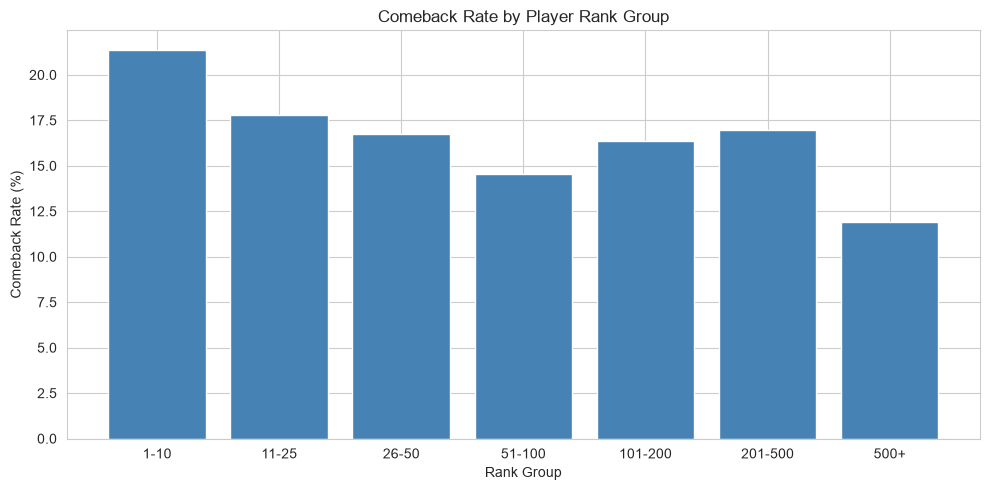

In [119]:
rank_bins   = [0, 10, 25, 50, 100, 200, 500, np.inf]
rank_labels = ['1-10', '11-25', '26-50', '51-100', '101-200', '201-500', '500+']

player_df_cb['rank_group'] = pd.cut(player_df_cb['rank'], bins=rank_bins, labels=rank_labels)

result_cb = (
    player_df_cb.groupby('rank_group', observed=True)
    .agg(total_situations=('total_sit', 'sum'), total_converted=('total_con', 'sum'))
    .reset_index())
result_cb['comeback_rate'] = (result_cb['total_converted'] / result_cb['total_situations'] * 100).round(2)

print('Comeback Rate by Player Rank Group:')
print(result_cb.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.bar(result_cb['rank_group'].astype(str), result_cb['comeback_rate'],
        color='steelblue', edgecolor='white')
plt.title('Comeback Rate by Player Rank Group')
plt.xlabel('Rank Group')
plt.ylabel('Comeback Rate (%)')
plt.tight_layout()
plt.savefig('optional_3_comeback_rate_by_rank.png', dpi=300, bbox_inches='tight')
plt.show()

- The comeback rate was highest for players ranked 1–10, while players ranked 500+ had the lowest rate. Overall, We cannot conclude that players with better rankings are more likely to make a comeback.

### Optional Question 4
**What is the comeback rate for players from each country?**

Continues from Optional Question 3, using the `comebacks` dataframe.

Countries with >= 100 situations: 49

       country  total_situations  total_converted  comeback_rate
     HONG KONG             108.0             23.0          21.30
    KAZAKHSTAN             260.0             53.0          20.38
        LATVIA             133.0             27.0          20.30
         CHILE             214.0             40.0          18.69
       GEORGIA             158.0             29.0          18.35
       CROATIA             293.0             53.0          18.09
      SLOVAKIA             457.0             81.0          17.72
          PERU             127.0             22.0          17.32
      PORTUGAL             334.0             55.0          16.47
     ARGENTINA            1219.0            197.0          16.16
   NETHERLANDS             540.0             86.0          15.93
      BULGARIA             327.0             52.0          15.90
     AUSTRALIA            1116.0            176.0          15.77
       ROMANIA             674.0            106.0   

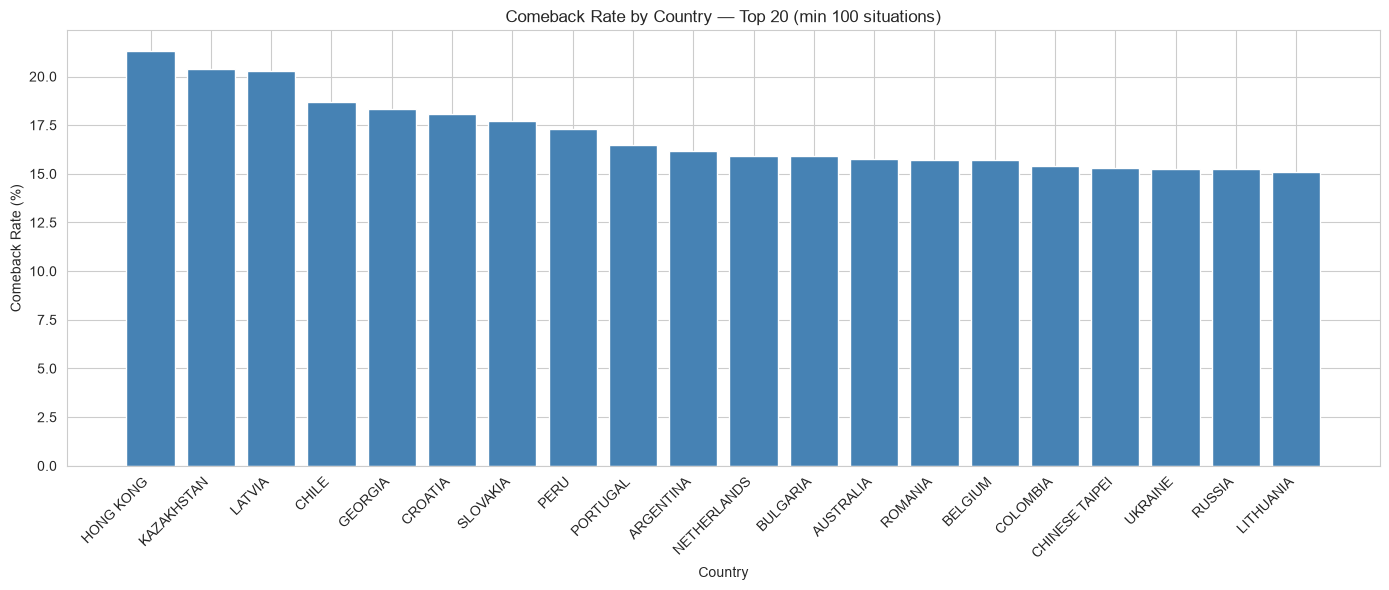

In [120]:
def clean_team_for_country(df):
    df = df.dropna(subset=['match_id', 'current_rank']).copy()
    df = df[df['current_rank'] > 0].drop_duplicates(subset=['match_id'])
    return df

home_cb_ctry = clean_team_for_country(home_team)
away_cb_ctry = clean_team_for_country(away_team)

home_ctry = (home_cb_ctry[['match_id', 'country']].dropna()
             .drop_duplicates(subset=['match_id'])
             .rename(columns={'country': 'home_country'}))
away_ctry = (away_cb_ctry[['match_id', 'country']].dropna()
             .drop_duplicates(subset=['match_id'])
             .rename(columns={'country': 'away_country'}))

comebacks_ctry = comebacks.merge(home_ctry, on='match_id').merge(away_ctry, on='match_id')

home_rows_ctry = comebacks_ctry[['match_id', 'home_country', 'home_total_sit', 'home_total_con']].rename(
    columns={'home_country': 'country', 'home_total_sit': 'total_sit', 'home_total_con': 'total_con'})
away_rows_ctry = comebacks_ctry[['match_id', 'away_country', 'away_total_sit', 'away_total_con']].rename(
    columns={'away_country': 'country', 'away_total_sit': 'total_sit', 'away_total_con': 'total_con'})

player_ctry_df = pd.concat([home_rows_ctry, away_rows_ctry], ignore_index=True)
player_ctry_df['country'] = player_ctry_df['country'].str.strip().str.upper()
player_ctry_df = player_ctry_df.dropna(subset=['country'])
player_ctry_df = player_ctry_df[player_ctry_df['total_sit'] > 0]

result_ctry = (
    player_ctry_df.groupby('country')
    .agg(total_situations=('total_sit', 'sum'), total_converted=('total_con', 'sum'))
    .reset_index())
result_ctry['comeback_rate'] = (result_ctry['total_converted'] / result_ctry['total_situations'] * 100).round(2)

MIN_SIT = 100
result_ctry = result_ctry[result_ctry['total_situations'] >= MIN_SIT].sort_values(
    'comeback_rate', ascending=False).reset_index(drop=True)

print(f'Countries with >= {MIN_SIT} situations: {len(result_ctry)}\n')
print(result_ctry.head(20).to_string(index=False))

top20_ctry = result_ctry.head(20)
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(top20_ctry['country'], top20_ctry['comeback_rate'],
       color='steelblue', edgecolor='white')
ax.set_title(f'Comeback Rate by Country — Top 20 (min {MIN_SIT} situations)')
ax.set_xlabel('Country')
ax.set_ylabel('Comeback Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('optional_4_comeback_rate_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

- Hong Kong had the highest comeback rate at about **21%**, while Lithuania had the lowest at about **15%**. Overall, the comeback rates were fairly close across the top 20 countries. As we can see, none of the top three most successful countries from Question 6 (America, France, and Italy) are in the top 20 for comeback rate. This may suggest that **staying ahead is more important for success than making a comeback**.

### Optional Question 5
**Is there a relationship between the number of double faults and a player's ranking?**

Unique players: 2452
Correlation (avg double faults vs rank): 0.0662


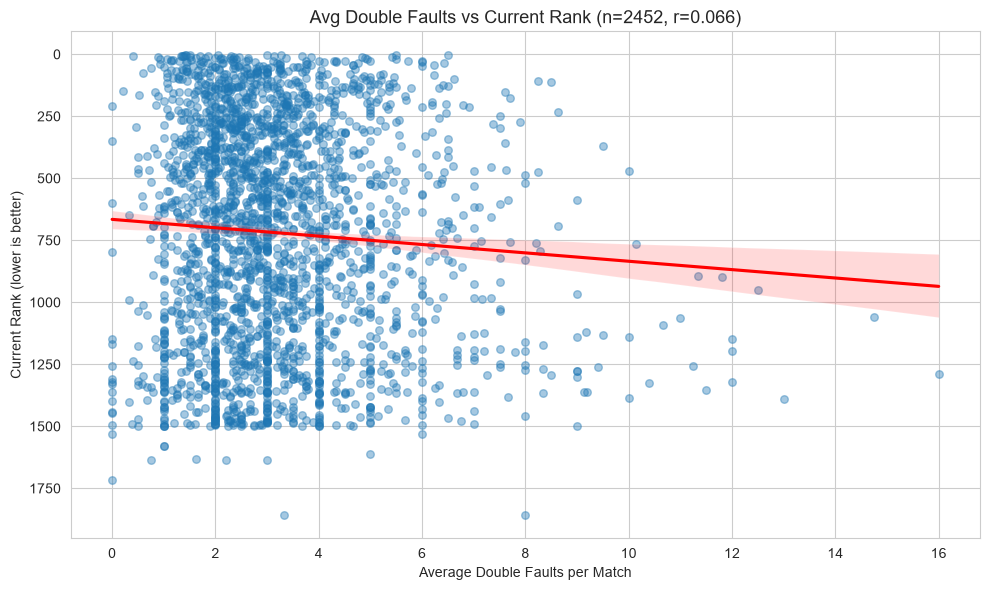

In [121]:
df_stats = stats_df[
    (stats_df['statistic_name'] == 'double_faults') &
    (stats_df['period'] == 'ALL')
].copy()
df_stats = df_stats.drop_duplicates().drop_duplicates(subset='match_id', keep='first')

df_stats['home_stat_num'] = pd.to_numeric(df_stats['home_stat'], errors='coerce')
df_stats['away_stat_num'] = pd.to_numeric(df_stats['away_stat'], errors='coerce')

home_faults = df_stats[['match_id', 'home_stat_num']].merge(
    home_team[['match_id', 'player_id', 'current_rank']], on='match_id')
home_faults = home_faults.rename(columns={'home_stat_num': 'double_faults'})

away_faults = df_stats[['match_id', 'away_stat_num']].merge(
    away_team[['match_id', 'player_id', 'current_rank']], on='match_id')
away_faults = away_faults.rename(columns={'away_stat_num': 'double_faults'})

player_match_faults = pd.concat([home_faults, away_faults], ignore_index=True)

player_avg_faults = player_match_faults.groupby('player_id').agg(
    avg_double_faults=('double_faults', 'mean'),
    num_matches=('match_id', 'count'),
    current_rank=('current_rank', 'first')).reset_index()

player_avg_faults_valid = player_avg_faults.dropna(subset=['current_rank'])
correlation = player_avg_faults_valid['avg_double_faults'].corr(player_avg_faults_valid['current_rank'])
print(f'Unique players: {len(player_avg_faults_valid)}')
print(f'Correlation (avg double faults vs rank): {correlation:.4f}')

plt.figure(figsize=(10, 6))
sns.regplot(data=player_avg_faults_valid, x='avg_double_faults', y='current_rank',
            scatter_kws={'alpha': 0.4, 's': 30}, line_kws={'color': 'red'})
plt.title(f'Avg Double Faults vs Current Rank (n={len(player_avg_faults_valid)}, r={correlation:.3f})',
          fontsize=13)
plt.xlabel('Average Double Faults per Match')
plt.ylabel('Current Rank (lower is better)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('optional_5_double_faults_vs_rank.png', dpi=300, bbox_inches='tight')
plt.show()

### Optional Question 6
**On which court surface are there the most double faults?**

Average double faults per match by surface:

                   mean  median   std  count
ground_type                                 
Synthetic outdoor  8.17     8.0  4.51     78
Grass              6.99     7.0  3.99    156
Green clay         6.44     5.0  3.58     18
Red clay           6.41     6.0  4.07   3445
Hardcourt outdoor  6.27     6.0  3.88   5160
Carpet indoor      6.22     6.0  2.95    120
Red clay indoor    6.02     5.0  3.67    191
Hardcourt indoor   5.77     5.0  3.68   2068


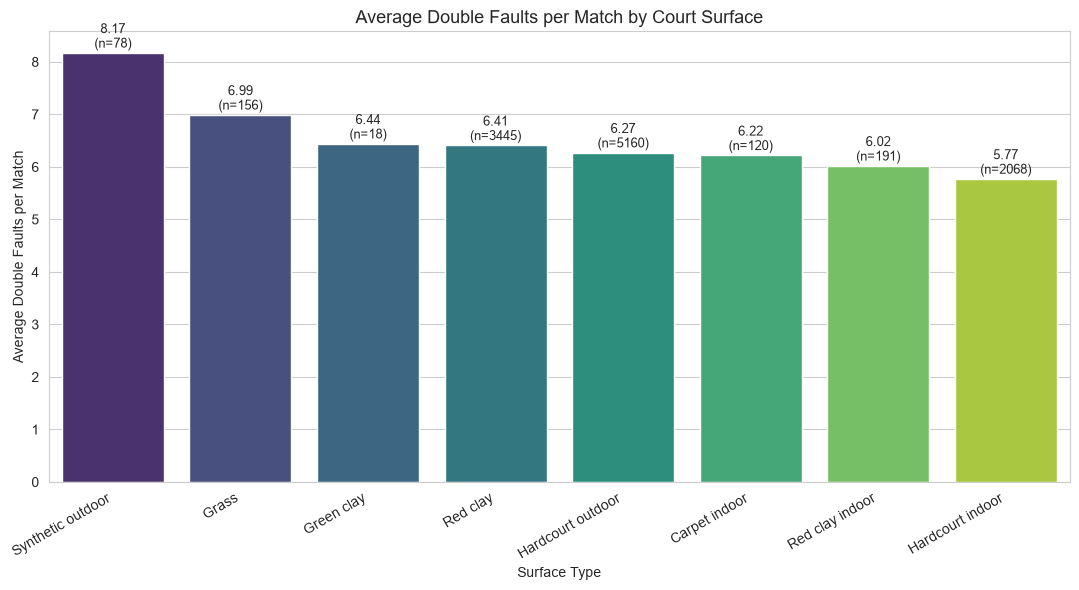

In [122]:
df_stats['total_double_faults'] = df_stats['home_stat_num'] + df_stats['away_stat_num']

faults_surf = df_stats[['match_id', 'total_double_faults']].merge(
    tournament_df[['match_id', 'ground_type']], on='match_id', how='inner')
faults_surf = faults_surf.dropna(subset=['ground_type'])

surface_summary = (
    faults_surf.groupby('ground_type')['total_double_faults']
    .agg(['mean', 'median', 'std', 'count'])
    .round(2)
    .sort_values('mean', ascending=False))

print('Average double faults per match by surface:\n')
print(surface_summary)

plt.figure(figsize=(11, 6))
ax = sns.barplot(x=surface_summary.index, y=surface_summary['mean'],
                 hue=surface_summary.index, palette='viridis', legend=False)
for i, (mean_val, count_val) in enumerate(zip(surface_summary['mean'], surface_summary['count'])):
    ax.text(i, mean_val + 0.1, f'{mean_val:.2f}\n(n={int(count_val)})', ha='center', fontsize=9)
plt.title('Average Double Faults per Match by Court Surface', fontsize=13)
plt.xlabel('Surface Type')
plt.ylabel('Average Double Faults per Match')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('optional_6_double_faults_by_surface.png', dpi=300, bbox_inches='tight')
plt.show()